In [16]:
import re
import sys
from pathlib import Path
from typing import Any, Tuple

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
import seaborn as sns
from scipy.stats import wasserstein_distance

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import DatasetPT, load_all_synthetic_variants, pytorch_to_igraph

In [17]:
DATASET_NAMES = ["BZR", "DHFR", "Mutagenicity", "MUTAG"]
METHODS = ["dummyNodes", "dummyEdges", "padma", "anndg", "anndgE", "nextGen"]
PALETTE = {
    "dummyNodes": "#DA7CF7",
    "dummyEdges": "#98C379", 
    "padma": "#F5C431", 
    "anndg": "#E06C75",
    "anndgE": "#C47900",
    "nextGen": "#5B9BD5", 
    "_": "#5CE9FF", 
    "__": "#5242D1", 
    }
NON_TARGETED_FEATURES = ["modularity", "clustering", "assortativity", "efficiency", "diameter"]
TARGETED_FEATURES = ["n_nodes", "n_edges", 
 "degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3", 
 "annd_0", "annd_1", "annd_2", "annd_3", 
 "eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"]
FEATURES = NON_TARGETED_FEATURES + TARGETED_FEATURES

def load_generation_data() -> pd.DataFrame:
    """Load and preprocess all original datasets and synthetic variants saving all per-graph statistics."""
    rows = []

    for dataset_name in DATASET_NAMES:
        # Load original
        orig_pt_path = PROJECT_ROOT / "data" / dataset_name / f"{dataset_name}_original.pt"
        if orig_pt_path.exists():
            dataset_obj = DatasetPT(orig_pt_path)
            per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])

            for i, stats in enumerate(per_graph_stats):                
                row = {
                    "dataset": dataset_name,
                    "method": "original",
                    "type": "original",
                    "graph_idx": i,
                    "variant_idx": -1,
                    "class_id": dataset_obj[i].y.item(),
                    "seed": pd.NA,
                }
                # Flatten the stats dictionary
                if stats:
                    for key, value in stats.items():
                        if isinstance(value, (list, np.ndarray)):
                            for idx, val in enumerate(value):
                                row[f"{key}_{idx}"] = val
                        else:
                            row[key] = value
                rows.append(row)
        else:
            print(f"Warning: Original dataset not found at {orig_pt_path}")
            
        # Load synthetic variants
        for method in METHODS:
            method_dir = PROJECT_ROOT / "synthetic_data" / dataset_name / method
            if not method_dir.exists():
                continue
            
            variant_paths = load_all_synthetic_variants(method_dir, dataset_name)
            for v_idx, v_path in enumerate(variant_paths):
                dataset_obj = DatasetPT(v_path)
                per_graph_target_stats = dataset_obj.metadata.get("per_graph_target_statistics", [])
                per_graph_stats = dataset_obj.metadata.get("per_graph_statistics", [])
                seeds = dataset_obj.metadata.get("seeds", [])
                
                n_graphs = len(dataset_obj)
                for i in range(n_graphs):
                    class_id = dataset_obj[i].y.item()
                    seed = seeds[i] if (seeds and i < len(seeds)) else pd.NA
                    
                    # 1. Target Stats
                    if i < len(per_graph_target_stats):
                        t_stats = per_graph_target_stats[i]
                        row = {
                            "dataset": dataset_name,
                            "method": method,
                            "type": "target",
                            "graph_idx": i,
                            "variant_idx": v_idx,
                            "class_id": class_id,
                            "seed": seed,
                        }
                        if t_stats:
                            for key, value in t_stats.items():
                                if isinstance(value, (list, np.ndarray)):
                                    for idx, val in enumerate(value):
                                        row[f"{key}_{idx}"] = val
                                else:
                                    row[key] = value
                        rows.append(row)
                        
                    # 2. Synthetic Stats
                    if i < len(per_graph_stats):
                        s_stats = per_graph_stats[i]
                        row = {
                            "dataset": dataset_name,
                            "method": method,
                            "type": "synthetic",
                            "graph_idx": i,
                            "variant_idx": v_idx,
                            "class_id": class_id,
                            "seed": seed,
                        }
                        if s_stats:
                            for key, value in s_stats.items():
                                if isinstance(value, (list, np.ndarray)):
                                    for idx, val in enumerate(value):
                                        row[f"{key}_{idx}"] = val
                                else:
                                    row[key] = value
                        rows.append(row)
    df = pd.DataFrame(rows)
    if "seed" in df.columns:
        df["seed"] = df["seed"].astype("Int64")
    return df

# Load data
df = load_generation_data()
display(df[df["method"]=="padma"])

,dataset,method,type,graph_idx,variant_idx,class_id,seed,n_nodes,n_edges,modularity,...,degree_moments_2,degree_moments_3,annd_0,annd_1,annd_2,annd_3,eccentricity_0,eccentricity_1,eccentricity_2,eccentricity_3
15228,MUTAG,padma,target,0,0,1,138990367,28,34,NaN,...,-0.536087,2.061809,0.114999,0.092643,0.115984,0.089680,0.359526,0.285651,0.227771,0.306885
15229,MUTAG,padma,synthetic,0,0,1,138990367,28,34,0.590830,...,-0.647414,2.191095,0.095238,0.111111,0.104056,0.094356,0.343915,0.238095,0.259259,0.243386
15230,MUTAG,padma,target,1,0,0,2075810619,21,22,NaN,...,-0.277560,1.334818,0.145843,0.125414,0.113605,0.104651,0.415955,0.352883,0.317438,0.349810
15231,MUTAG,padma,synthetic,1,0,0,2075810619,21,22,0.537190,...,-0.199345,1.231964,0.108333,0.115000,0.131667,0.123333,0.258333,0.400000,0.290000,0.330000
15232,MUTAG,padma,target,2,0,0,138163403,14,14,NaN,...,-0.390657,1.221276,0.218408,0.206696,0.179744,0.152579,0.513836,0.386534,0.311560,0.421941
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22743,MUTAG,padma,synthetic,185,19,0,74979881,13,14,0.438776,...,-0.203342,2.503792,0.208333,0.194444,0.203704,0.185185,0.437500,0.472222,0.333333,0.388889
22744,MUTAG,padma,target,186,19,1,1958865506,17,19,NaN,...,-0.353749,2.274497,0.164936,0.160123,0.145746,0.139910,0.511019,0.423410,0.393699,0.401924
22745,MUTAG,padma,synthetic,186,19,1,1958865506,17,19,0.500000,...,-0.291072,2.494857,0.156250,0.156250,0.164062,0.135417,0.512500,0.500000,0.500000,0.453125
22746,MUTAG,padma,target,187,19,0,1417996293,22,24,NaN,...,-0.405020,1.242148,0.142248,0.150050,0.103139,0.119224,0.439187,0.327802,0.360069,0.370468


In [18]:
def compute_target_synthetic_errors(df_dataset: pd.DataFrame, dataset_name: str) -> pd.DataFrame:
    """Computes absolute errors between target and synthetic targeted features.

    Args:
        df_dataset: A DataFrame containing original, target, and synthetic stats.
        dataset_name: The name of the dataset to filter and analyze.
    Returns:
        A DataFrame with computed absolute errors for targeted metrics.
    Raises:
        ValueError: If no target or synthetic records are found for the dataset.
    """
    df_subset = df_dataset[df_dataset["dataset"] == dataset_name]

    df_target = df_subset[df_subset["type"] == "target"]
    df_synth = df_subset[df_subset["type"] == "synthetic"]

    if df_target.empty or df_synth.empty:
        raise ValueError(f"No target or synthetic records found for dataset: {dataset_name}")

    keys = ["graph_idx", "method", "variant_idx"]
    df_target = df_target.set_index(keys)
    df_synth = df_synth.set_index(keys)

    # Align rows to ensure exact target-synthetic comparison
    common_idx = df_target.index.intersection(df_synth.index)
    if common_idx.empty:
        raise ValueError(f"No matching target-synthetic index pairs found for dataset: {dataset_name}")

    df_target = df_target.loc[common_idx]
    df_synth = df_synth.loc[common_idx]

    # Restrict errors to TARGETED_FEATURES present in the DataFrame
    active_features = [f for f in TARGETED_FEATURES if f in df_subset.columns]

    df_errors = (df_target[active_features] - df_synth[active_features]).abs()

    # Re-insert identifying metadata
    df_errors.insert(0, "dataset", dataset_name)
    df_errors.reset_index(inplace=True)
    df_errors["class_id"] = df_synth["class_id"].values

    if "seed" in df_synth.columns:
        df_errors["seed"] = df_synth["seed"].values

    return df_errors


def aggregate_and_display_errors(df_errors: pd.DataFrame) -> None:
    """Aggregates and prints target-synthetic errors by dataset and method."""
    # Ensure method column follows standard METHODS ordered category
    df_errors = df_errors.copy()
    df_errors["method"] = pd.Categorical(df_errors["method"], categories=METHODS, ordered=True)

    active_features = [f for f in TARGETED_FEATURES if f in df_errors.columns]

    print("\n" + "=" * 80)
    print("TARGET-SYNTHETIC ERROR BY DATASET AND METHOD (Mean & Std)")
    print("=" * 80)
    detailed_summary = df_errors.groupby(["dataset", "method"], observed=True)[active_features].agg(["mean", "std"])
    with pd.option_context("display.max_columns", None):
        display(detailed_summary)

    print("\n" + "=" * 80)
    print("GLOBAL TARGET-SYNTHETIC ERROR BY METHOD (Mean & Std)")
    print("=" * 80)
    global_summary = df_errors.groupby("method", observed=True)[active_features].agg(["mean", "std"])
    with pd.option_context("display.max_columns", None):
        display(global_summary)

all_errors = []

for dataset in DATASET_NAMES:
    try:
        df_err = compute_target_synthetic_errors(df, dataset)
        all_errors.append(df_err)
    except ValueError as e:
        print(f"Skipping dataset '{dataset}': {e}")
    except Exception as e:
        print(f"Unexpected error processing '{dataset}': {e}")

if all_errors:
    df_all_errors = pd.concat(all_errors, ignore_index=True)
    aggregate_and_display_errors(df_all_errors)
else:
    print("No target-synthetic error data found across any datasets.")

Skipping dataset 'BZR': No target or synthetic records found for dataset: BZR
Skipping dataset 'DHFR': No target or synthetic records found for dataset: DHFR
Skipping dataset 'Mutagenicity': No target or synthetic records found for dataset: Mutagenicity

TARGET-SYNTHETIC ERROR BY DATASET AND METHOD (Mean & Std)


n_nodes        n_edges           degree_moments_0  \
                      mean  std      mean       std             mean   
dataset method                                                         
MUTAG   dummyNodes     0.0  0.0  5.130851  4.263645         0.035078   
        dummyEdges     0.0  0.0  0.000000  0.000000         0.001462   
        padma          0.0  0.0  0.189628  0.392059         0.001934   
        anndg          0.0  0.0  0.187500  0.390364         0.001849   
        anndgE         0.0  0.0  0.186436  0.389510         0.001819   

                             degree_moments_1           degree_moments_2  \
                         std             mean       std             mean   
dataset method                                                             
MUTAG   dummyNodes  0.026993         0.004550  0.003681         0.756300   
        dummyEdges  0.001405         0.004545  0.003299         0.737823   
        padma       0.002106         0.000235  0.000319         0.107590   
        anndg       0.001991         0.000228  0.000328         0.103720   
        anndgE      0.001971         0.000212  0.000311         0.105653   

                             degree_moments_3              annd_0            \
                         std             mean       std      mean       std   
dataset method                                                                
MUTAG   dummyNodes  0.488237         1.171037  1.175828  0.051616  0.043227   
        dummyEdges  0.487195         1.155846  1.172808  0.039638  0.034937   
        padma       0.100745         0.197453  0.214692  0.022860  0.024531   
        anndg       0.098735         0.198676  0.226504  0.003081  0.003926   
        anndgE      0.096884         0.176551  0.187731  0.004005  0.004990   

                      annd_1              annd_2              annd_3  \
                        mean       std      mean       std      mean   
dataset method                                                         
MUTAG   dummyNodes  0.053015  0.043464  0.049728  0.039338  0.045918   
        dummyEdges  0.041532  0.034520  0.038182  0.030327  0.035580   
        padma       0.015231  0.015437  0.013721  0.013017  0.017197   
        anndg       0.003219  0.004367  0.003842  0.005306  0.004165   
        anndgE      0.004124  0.005146  0.004722  0.005761  0.005093   

                             eccentricity_0           eccentricity_1  \
                         std           mean       std           mean   
dataset method                                                         
MUTAG   dummyNodes  0.035635       0.180921  0.101009       0.125943   
        dummyEdges  0.021808       0.147859  0.093598       0.098323   
        padma       0.015245       0.103952  0.087665       0.068777   
        anndg       0.005450       0.085991  0.070858       0.063795   
        anndgE      0.005612       0.017784  0.019096       0.014824   

                             eccentricity_2           eccentricity_3            
                         std           mean       std           mean       std  
dataset method                                                                  
MUTAG   dummyNodes  0.073689       0.107351  0.068161       0.134250  0.078903  
        dummyEdges  0.064114       0.085368  0.057253       0.113195  0.073058  
        padma       0.058602       0.065514  0.055402       0.075617  0.063090  
        anndg       0.056229       0.062157  0.056298       0.070093  0.060982  
        anndgE      0.016802       0.014502  0.016173       0.014382  0.015649


GLOBAL TARGET-SYNTHETIC ERROR BY METHOD (Mean & Std)


n_nodes        n_edges           degree_moments_0            \
              mean  std      mean       std             mean       std   
method                                                                   
dummyNodes     0.0  0.0  5.130851  4.263645         0.035078  0.026993   
dummyEdges     0.0  0.0  0.000000  0.000000         0.001462  0.001405   
padma          0.0  0.0  0.189628  0.392059         0.001934  0.002106   
anndg          0.0  0.0  0.187500  0.390364         0.001849  0.001991   
anndgE         0.0  0.0  0.186436  0.389510         0.001819  0.001971   

           degree_moments_1           degree_moments_2            \
                       mean       std             mean       std   
method                                                             
dummyNodes         0.004550  0.003681         0.756300  0.488237   
dummyEdges         0.004545  0.003299         0.737823  0.487195   
padma              0.000235  0.000319         0.107590  0.100745   
anndg              0.000228  0.000328         0.103720  0.098735   
anndgE             0.000212  0.000311         0.105653  0.096884   

           degree_moments_3              annd_0              annd_1            \
                       mean       std      mean       std      mean       std   
method                                                                          
dummyNodes         1.171037  1.175828  0.051616  0.043227  0.053015  0.043464   
dummyEdges         1.155846  1.172808  0.039638  0.034937  0.041532  0.034520   
padma              0.197453  0.214692  0.022860  0.024531  0.015231  0.015437   
anndg              0.198676  0.226504  0.003081  0.003926  0.003219  0.004367   
anndgE             0.176551  0.187731  0.004005  0.004990  0.004124  0.005146   

              annd_2              annd_3           eccentricity_0            \
                mean       std      mean       std           mean       std   
method                                                                        
dummyNodes  0.049728  0.039338  0.045918  0.035635       0.180921  0.101009   
dummyEdges  0.038182  0.030327  0.035580  0.021808       0.147859  0.093598   
padma       0.013721  0.013017  0.017197  0.015245       0.103952  0.087665   
anndg       0.003842  0.005306  0.004165  0.005450       0.085991  0.070858   
anndgE      0.004722  0.005761  0.005093  0.005612       0.017784  0.019096   

           eccentricity_1           eccentricity_2           eccentricity_3  \
                     mean       std           mean       std           mean   
method                                                                        
dummyNodes       0.125943  0.073689       0.107351  0.068161       0.134250   
dummyEdges       0.098323  0.064114       0.085368  0.057253       0.113195   
padma            0.068777  0.058602       0.065514  0.055402       0.075617   
anndg            0.063795  0.056229       0.062157  0.056298       0.070093   
anndgE           0.014824  0.016802       0.014502  0.016173       0.014382   

                      
                 std  
method                
dummyNodes  0.078903  
dummyEdges  0.073058  
padma       0.063090  
anndg       0.060982  
anndgE      0.015649

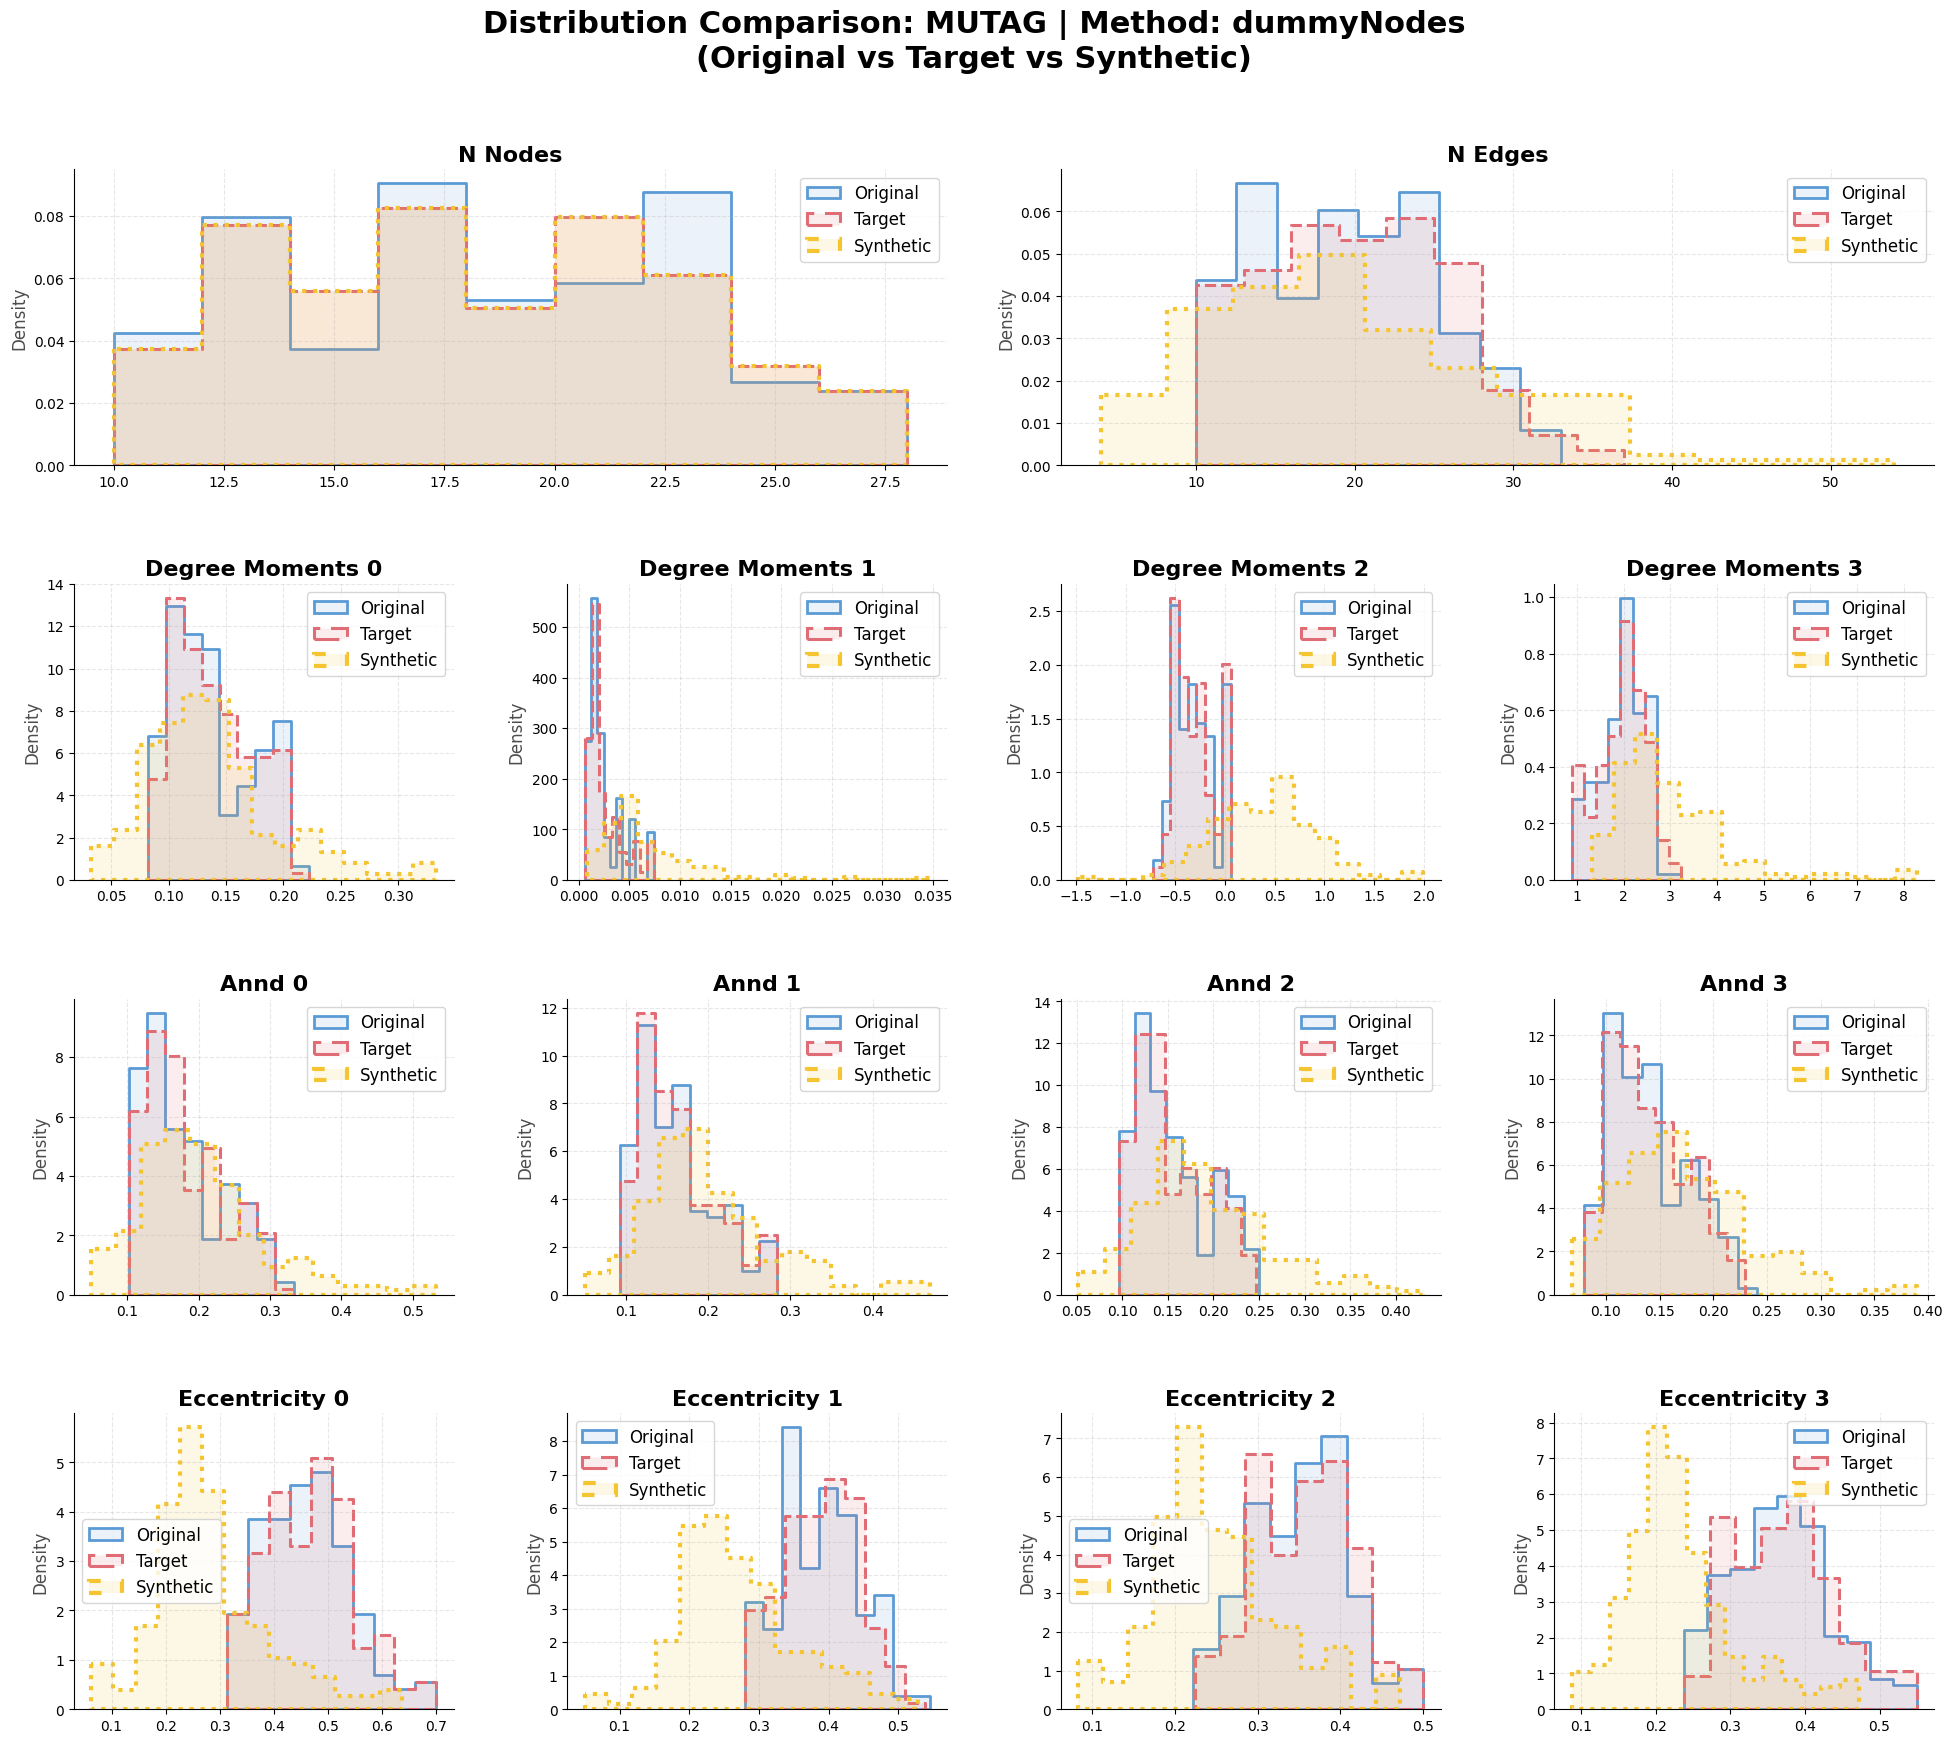


WASSERSTEIN DISTANCES - METHOD: dummyNodes


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
MUTAG target     0.019888  0.025278          0.023329          0.019030   
      synthetic  0.019888  0.114685          0.114178          0.664319   
MEAN  target     0.019888  0.025278          0.023329          0.019030   
      synthetic  0.019888  0.114685          0.114178          0.664319   

                 degree_moments_2  degree_moments_3    annd_0    annd_1  \
MUTAG target             0.022588          0.025129  0.019252  0.018083   
      synthetic          0.896463          0.434764  0.119329  0.206752   
MEAN  target             0.022588          0.025129  0.019252  0.018083   
      synthetic          0.896463          0.434764  0.119329  0.206752   

                   annd_2    annd_3  eccentricity_0  eccentricity_1  \
MUTAG target     0.020396  0.019131        0.018324        0.020368   
      synthetic  0.257892  0.225214        0.446738        0.439276   
MEAN  target     0.020396  0.019131        0.018324        0.020368   
      synthetic  0.257892  0.225214        0.446738        0.439276   

                 eccentricity_2  eccentricity_3  Global_Score  
MUTAG target           0.018955        0.020315      0.020719  
      synthetic        0.343777        0.408094      0.335098  
MEAN  target           0.018955        0.020315      0.020719  
      synthetic        0.343777        0.408094      0.335098

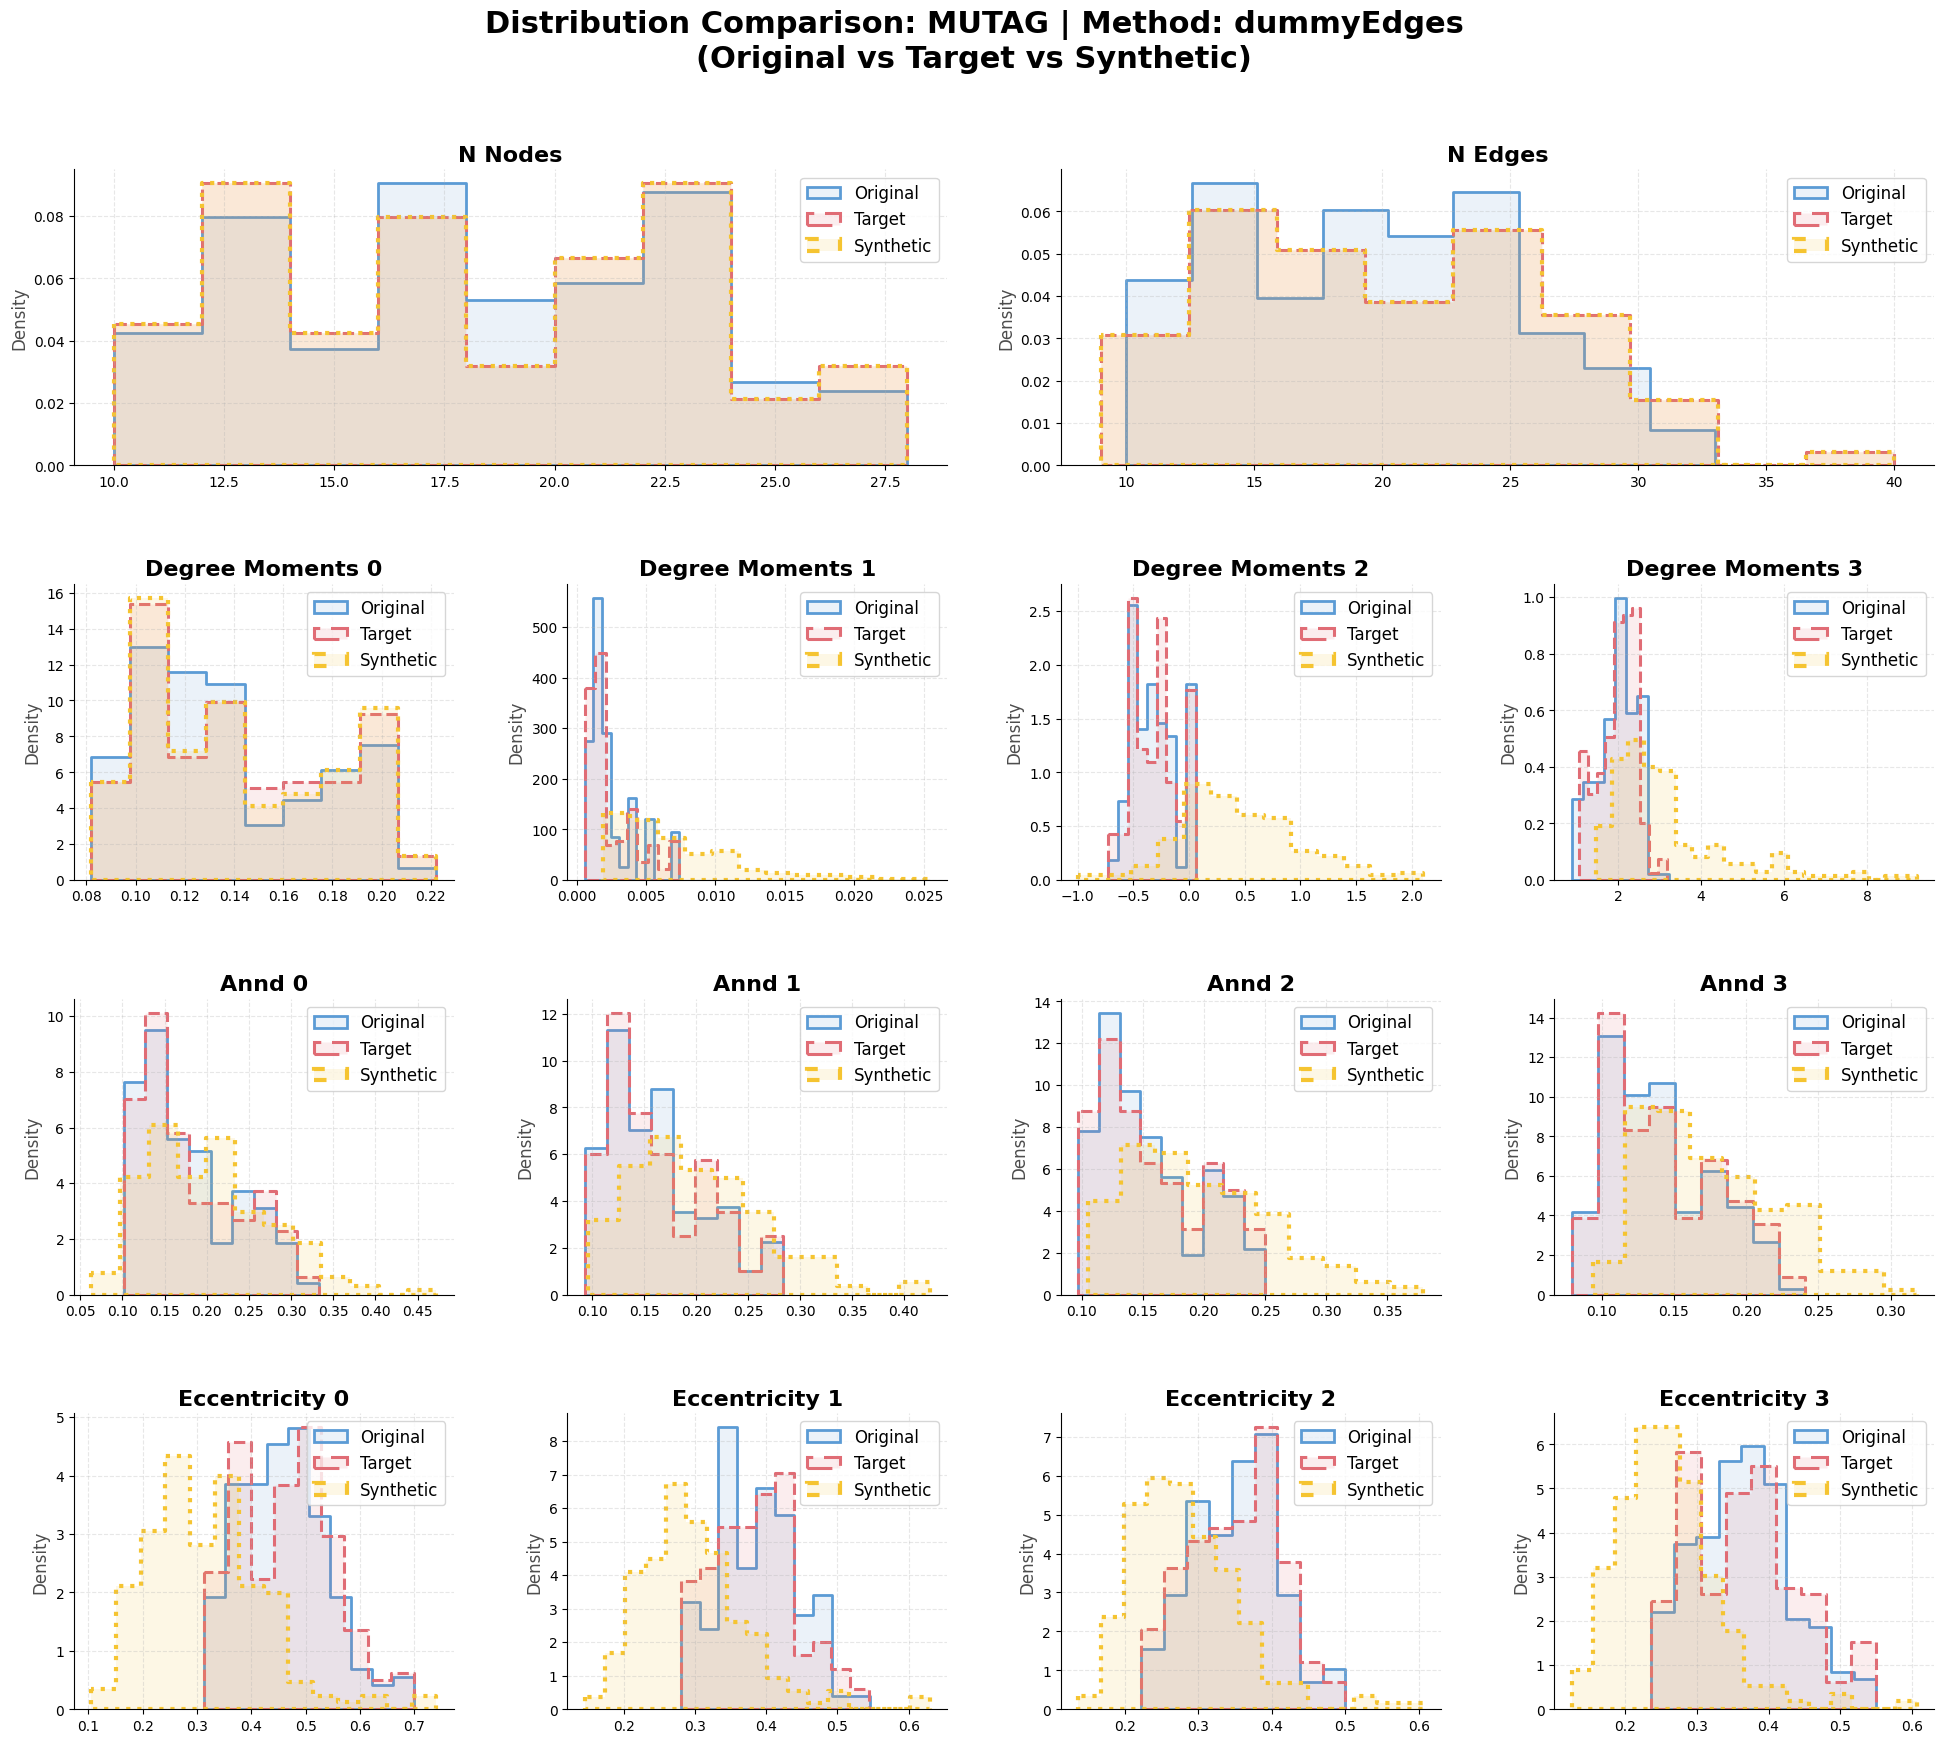


WASSERSTEIN DISTANCES - METHOD: dummyEdges


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
MUTAG target     0.020361  0.025046          0.022248          0.020076   
      synthetic  0.020361  0.025046          0.021168          0.659883   
MEAN  target     0.020361  0.025046          0.022248          0.020076   
      synthetic  0.020361  0.025046          0.021168          0.659883   

                 degree_moments_2  degree_moments_3    annd_0    annd_1  \
MUTAG target             0.020999          0.020715  0.017459  0.018788   
      synthetic          0.874365          0.433461  0.092176  0.187784   
MEAN  target             0.020999          0.020715  0.017459  0.018788   
      synthetic          0.874365          0.433461  0.092176  0.187784   

                   annd_2    annd_3  eccentricity_0  eccentricity_1  \
MUTAG target     0.019209  0.020326        0.018436        0.022935   
      synthetic  0.234479  0.211262        0.357280        0.326977   
MEAN  target     0.019209  0.020326        0.018436        0.022935   
      synthetic  0.234479  0.211262        0.357280        0.326977   

                 eccentricity_2  eccentricity_3  Global_Score  
MUTAG target           0.019901        0.022209      0.020622  
      synthetic        0.255854        0.333963      0.288147  
MEAN  target           0.019901        0.022209      0.020622  
      synthetic        0.255854        0.333963      0.288147

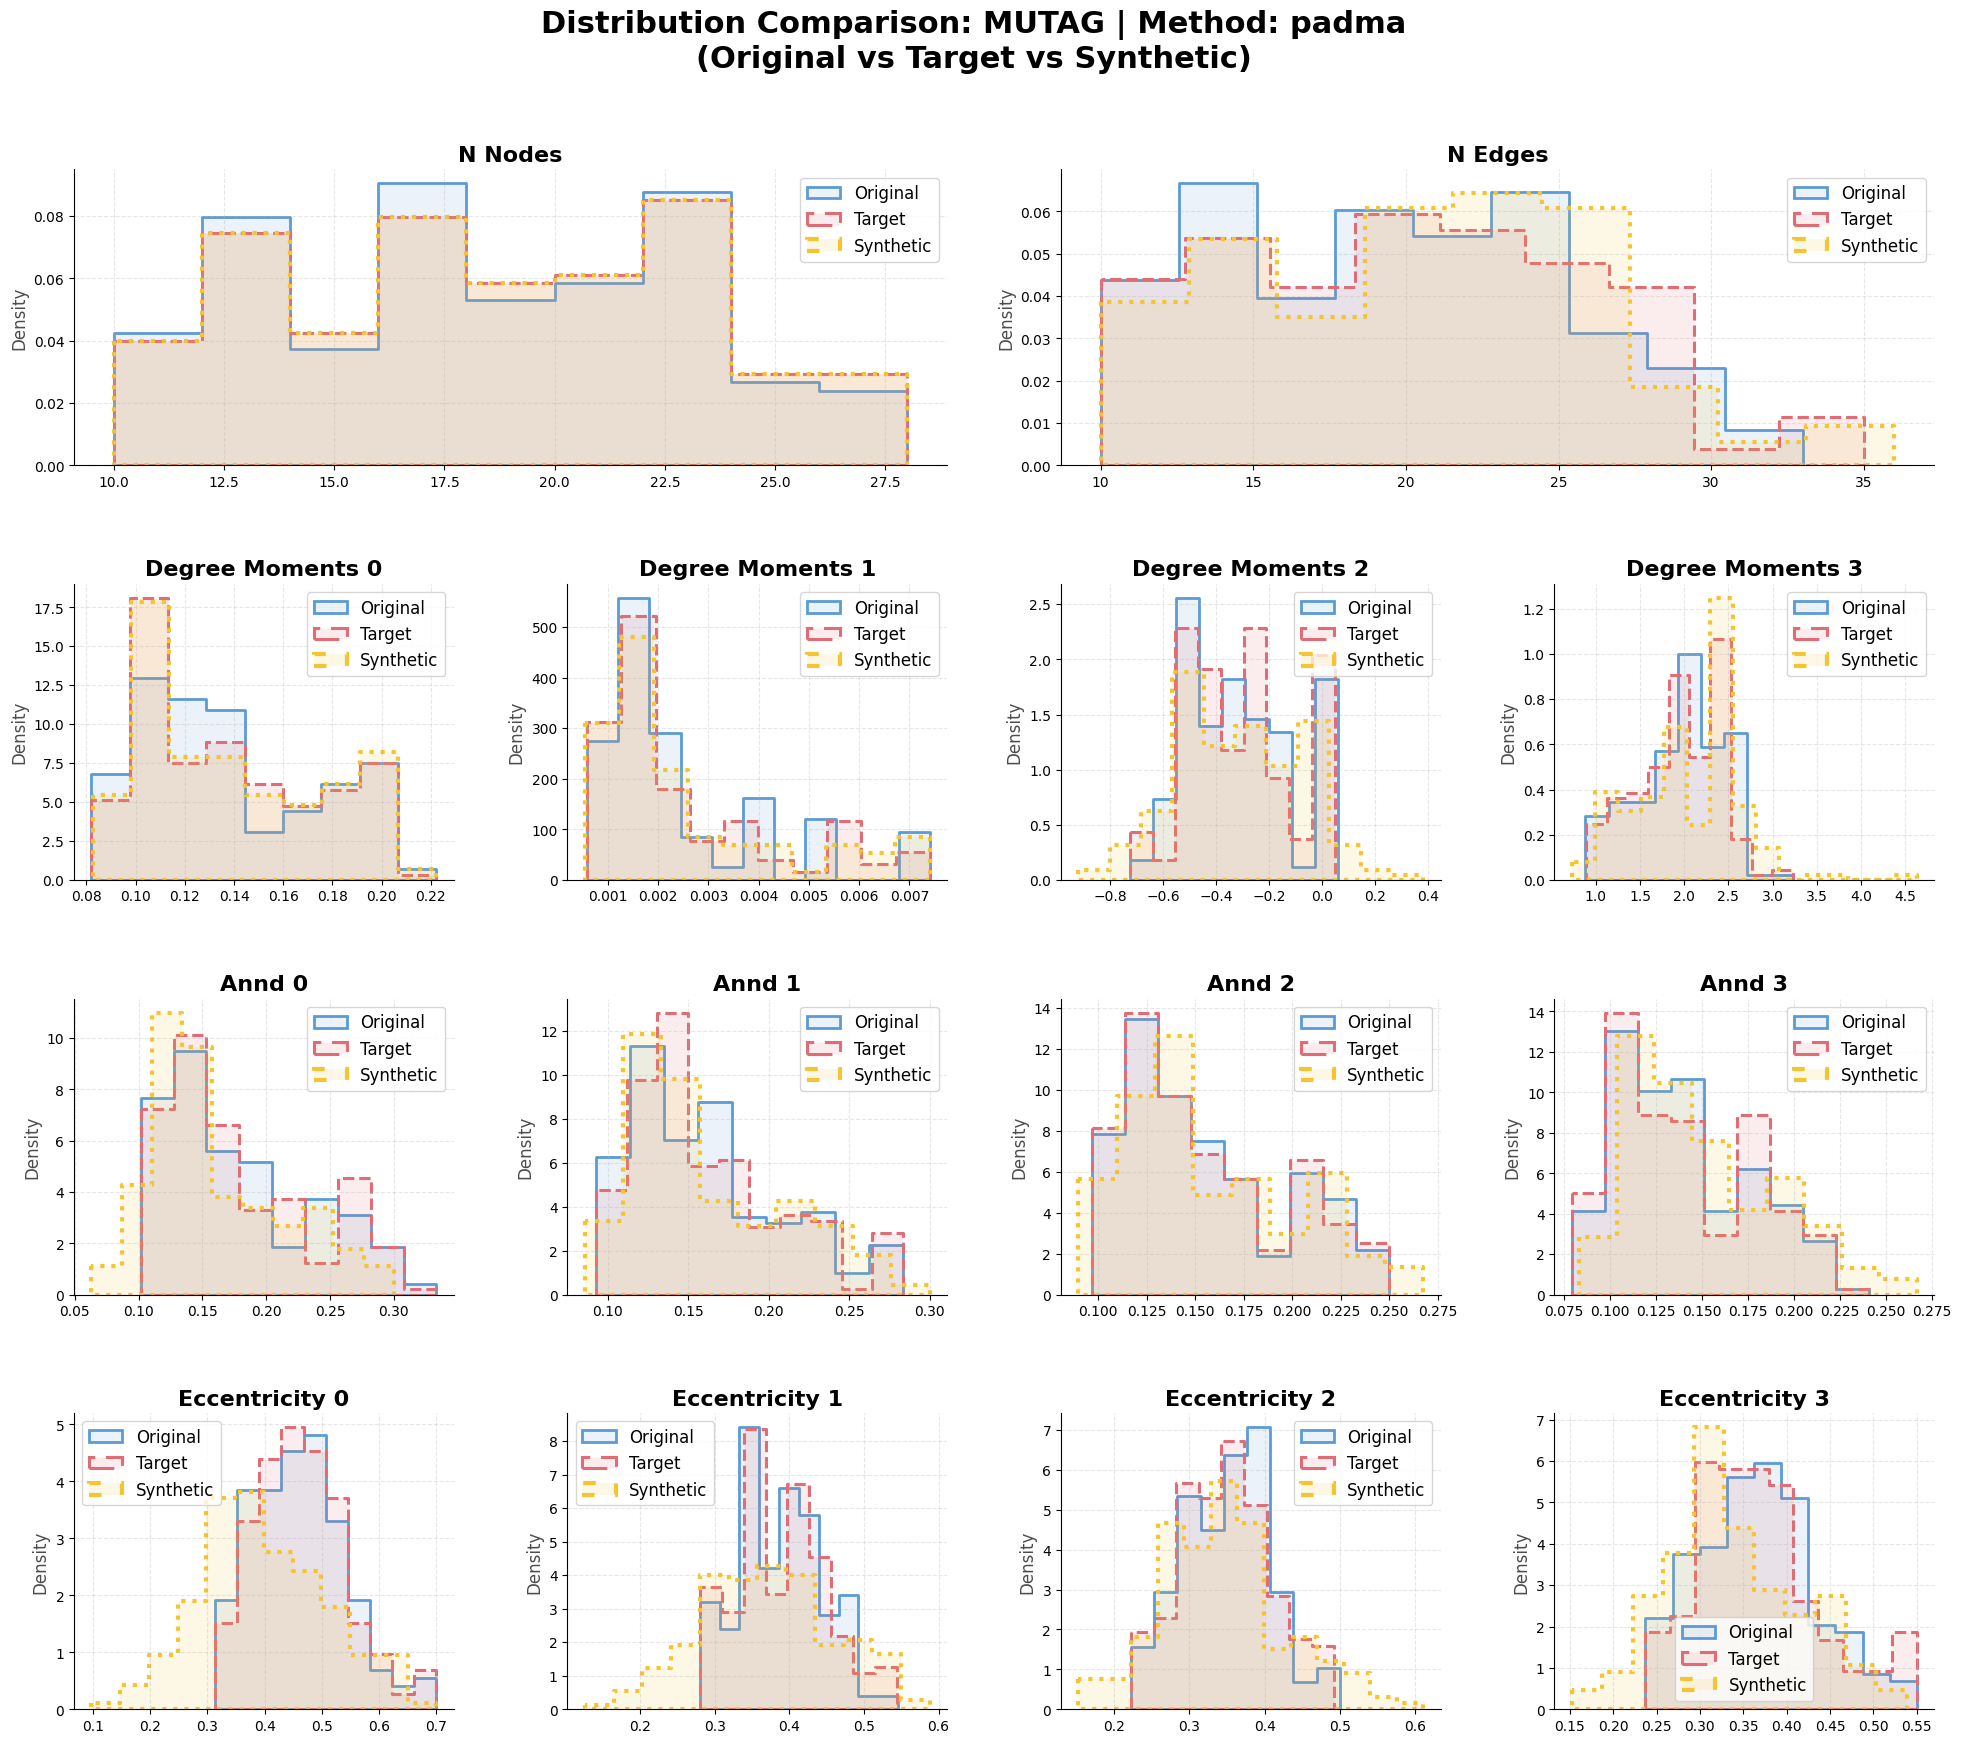


WASSERSTEIN DISTANCES - METHOD: padma


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
MUTAG target     0.02042  0.023520          0.023625          0.024736   
      synthetic  0.02042  0.025775          0.025521          0.029482   
MEAN  target     0.02042  0.023520          0.023625          0.024736   
      synthetic  0.02042  0.025775          0.025521          0.029482   

                 degree_moments_2  degree_moments_3    annd_0    annd_1  \
MUTAG target             0.023032          0.026690  0.021032  0.020991   
      synthetic          0.061491          0.047108  0.074245  0.023739   
MEAN  target             0.023032          0.026690  0.021032  0.020991   
      synthetic          0.061491          0.047108  0.074245  0.023739   

                   annd_2    annd_3  eccentricity_0  eccentricity_1  \
MUTAG target     0.021932  0.020023        0.018825        0.022819   
      synthetic  0.029546  0.082738        0.165561        0.118433   
MEAN  target     0.021932  0.020023        0.018825        0.022819   
      synthetic  0.029546  0.082738        0.165561        0.118433   

                 eccentricity_2  eccentricity_3  Global_Score  
MUTAG target           0.023336        0.021857      0.022346  
      synthetic        0.088118        0.087775      0.062854  
MEAN  target           0.023336        0.021857      0.022346  
      synthetic        0.088118        0.087775      0.062854

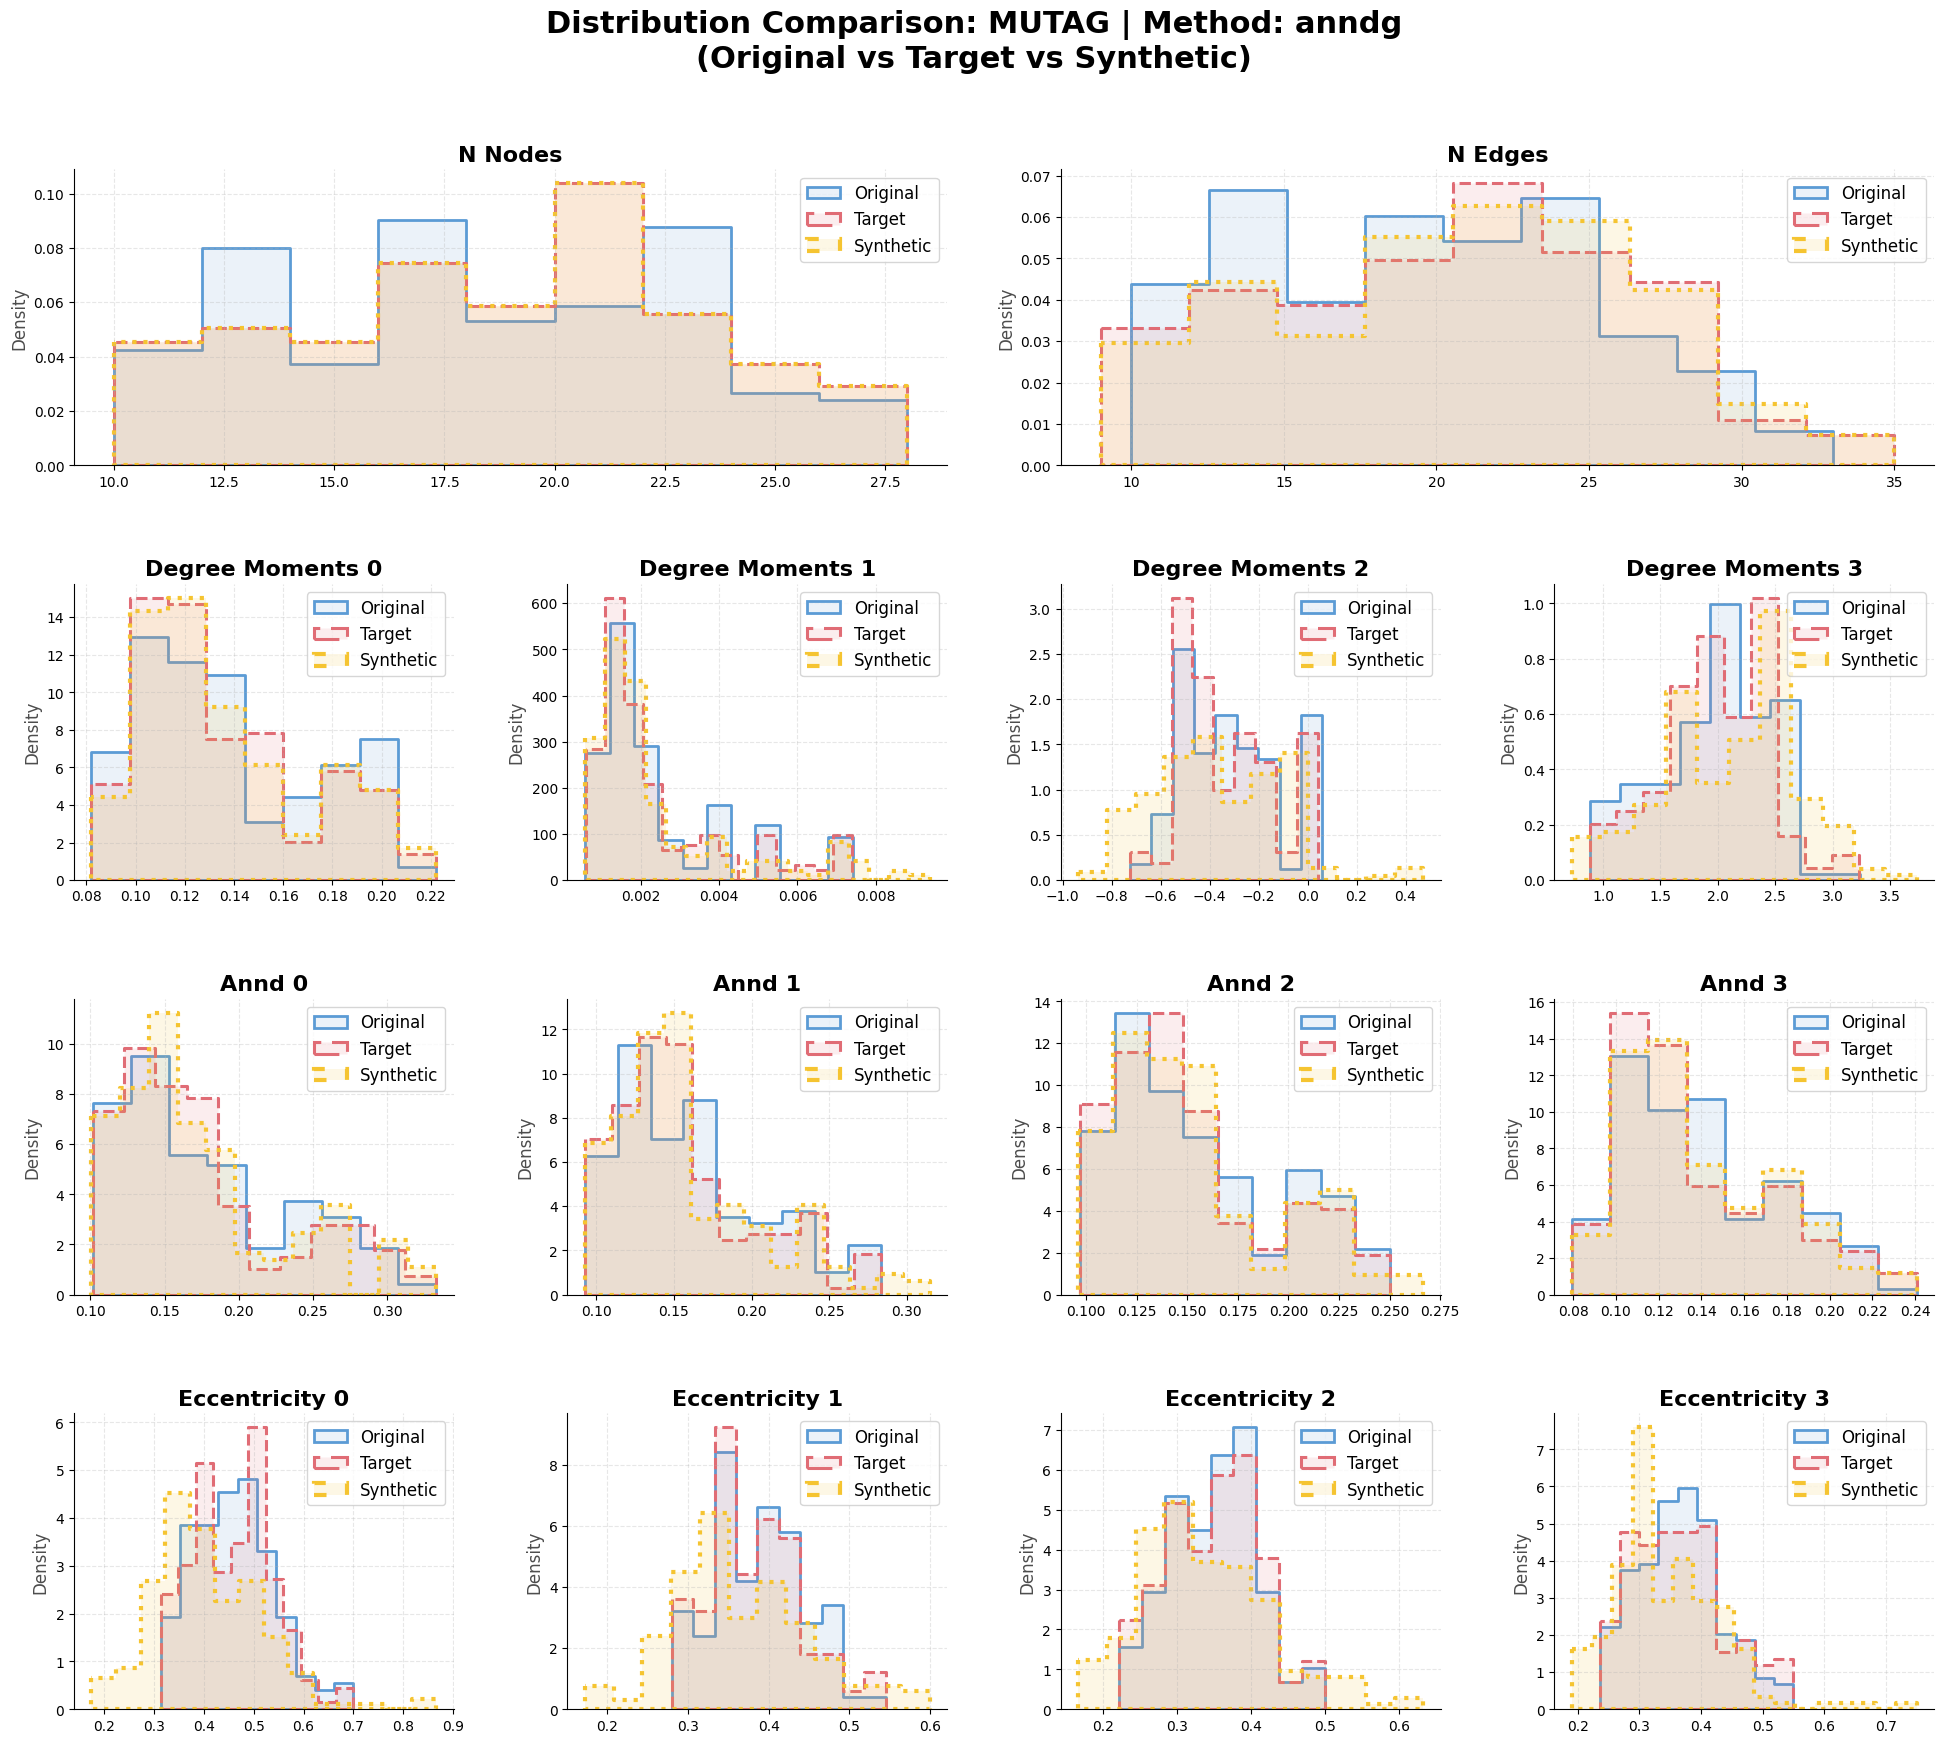


WASSERSTEIN DISTANCES - METHOD: anndg


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
MUTAG target     0.02104  0.026943          0.022155          0.021397   
      synthetic  0.02104  0.029683          0.023166          0.026692   
MEAN  target     0.02104  0.026943          0.022155          0.021397   
      synthetic  0.02104  0.029683          0.023166          0.026692   

                 degree_moments_2  degree_moments_3    annd_0    annd_1  \
MUTAG target             0.022207          0.028173  0.019292  0.020678   
      synthetic          0.069827          0.060465  0.019009  0.020897   
MEAN  target             0.022207          0.028173  0.019292  0.020678   
      synthetic          0.069827          0.060465  0.019009  0.020897   

                   annd_2    annd_3  eccentricity_0  eccentricity_1  \
MUTAG target     0.022051  0.019857        0.020201        0.023107   
      synthetic  0.022153  0.020505        0.126228        0.104647   
MEAN  target     0.022051  0.019857        0.020201        0.023107   
      synthetic  0.022153  0.020505        0.126228        0.104647   

                 eccentricity_2  eccentricity_3  Global_Score  
MUTAG target           0.022374        0.024316      0.022414  
      synthetic        0.087799        0.069446      0.050111  
MEAN  target           0.022374        0.024316      0.022414  
      synthetic        0.087799        0.069446      0.050111

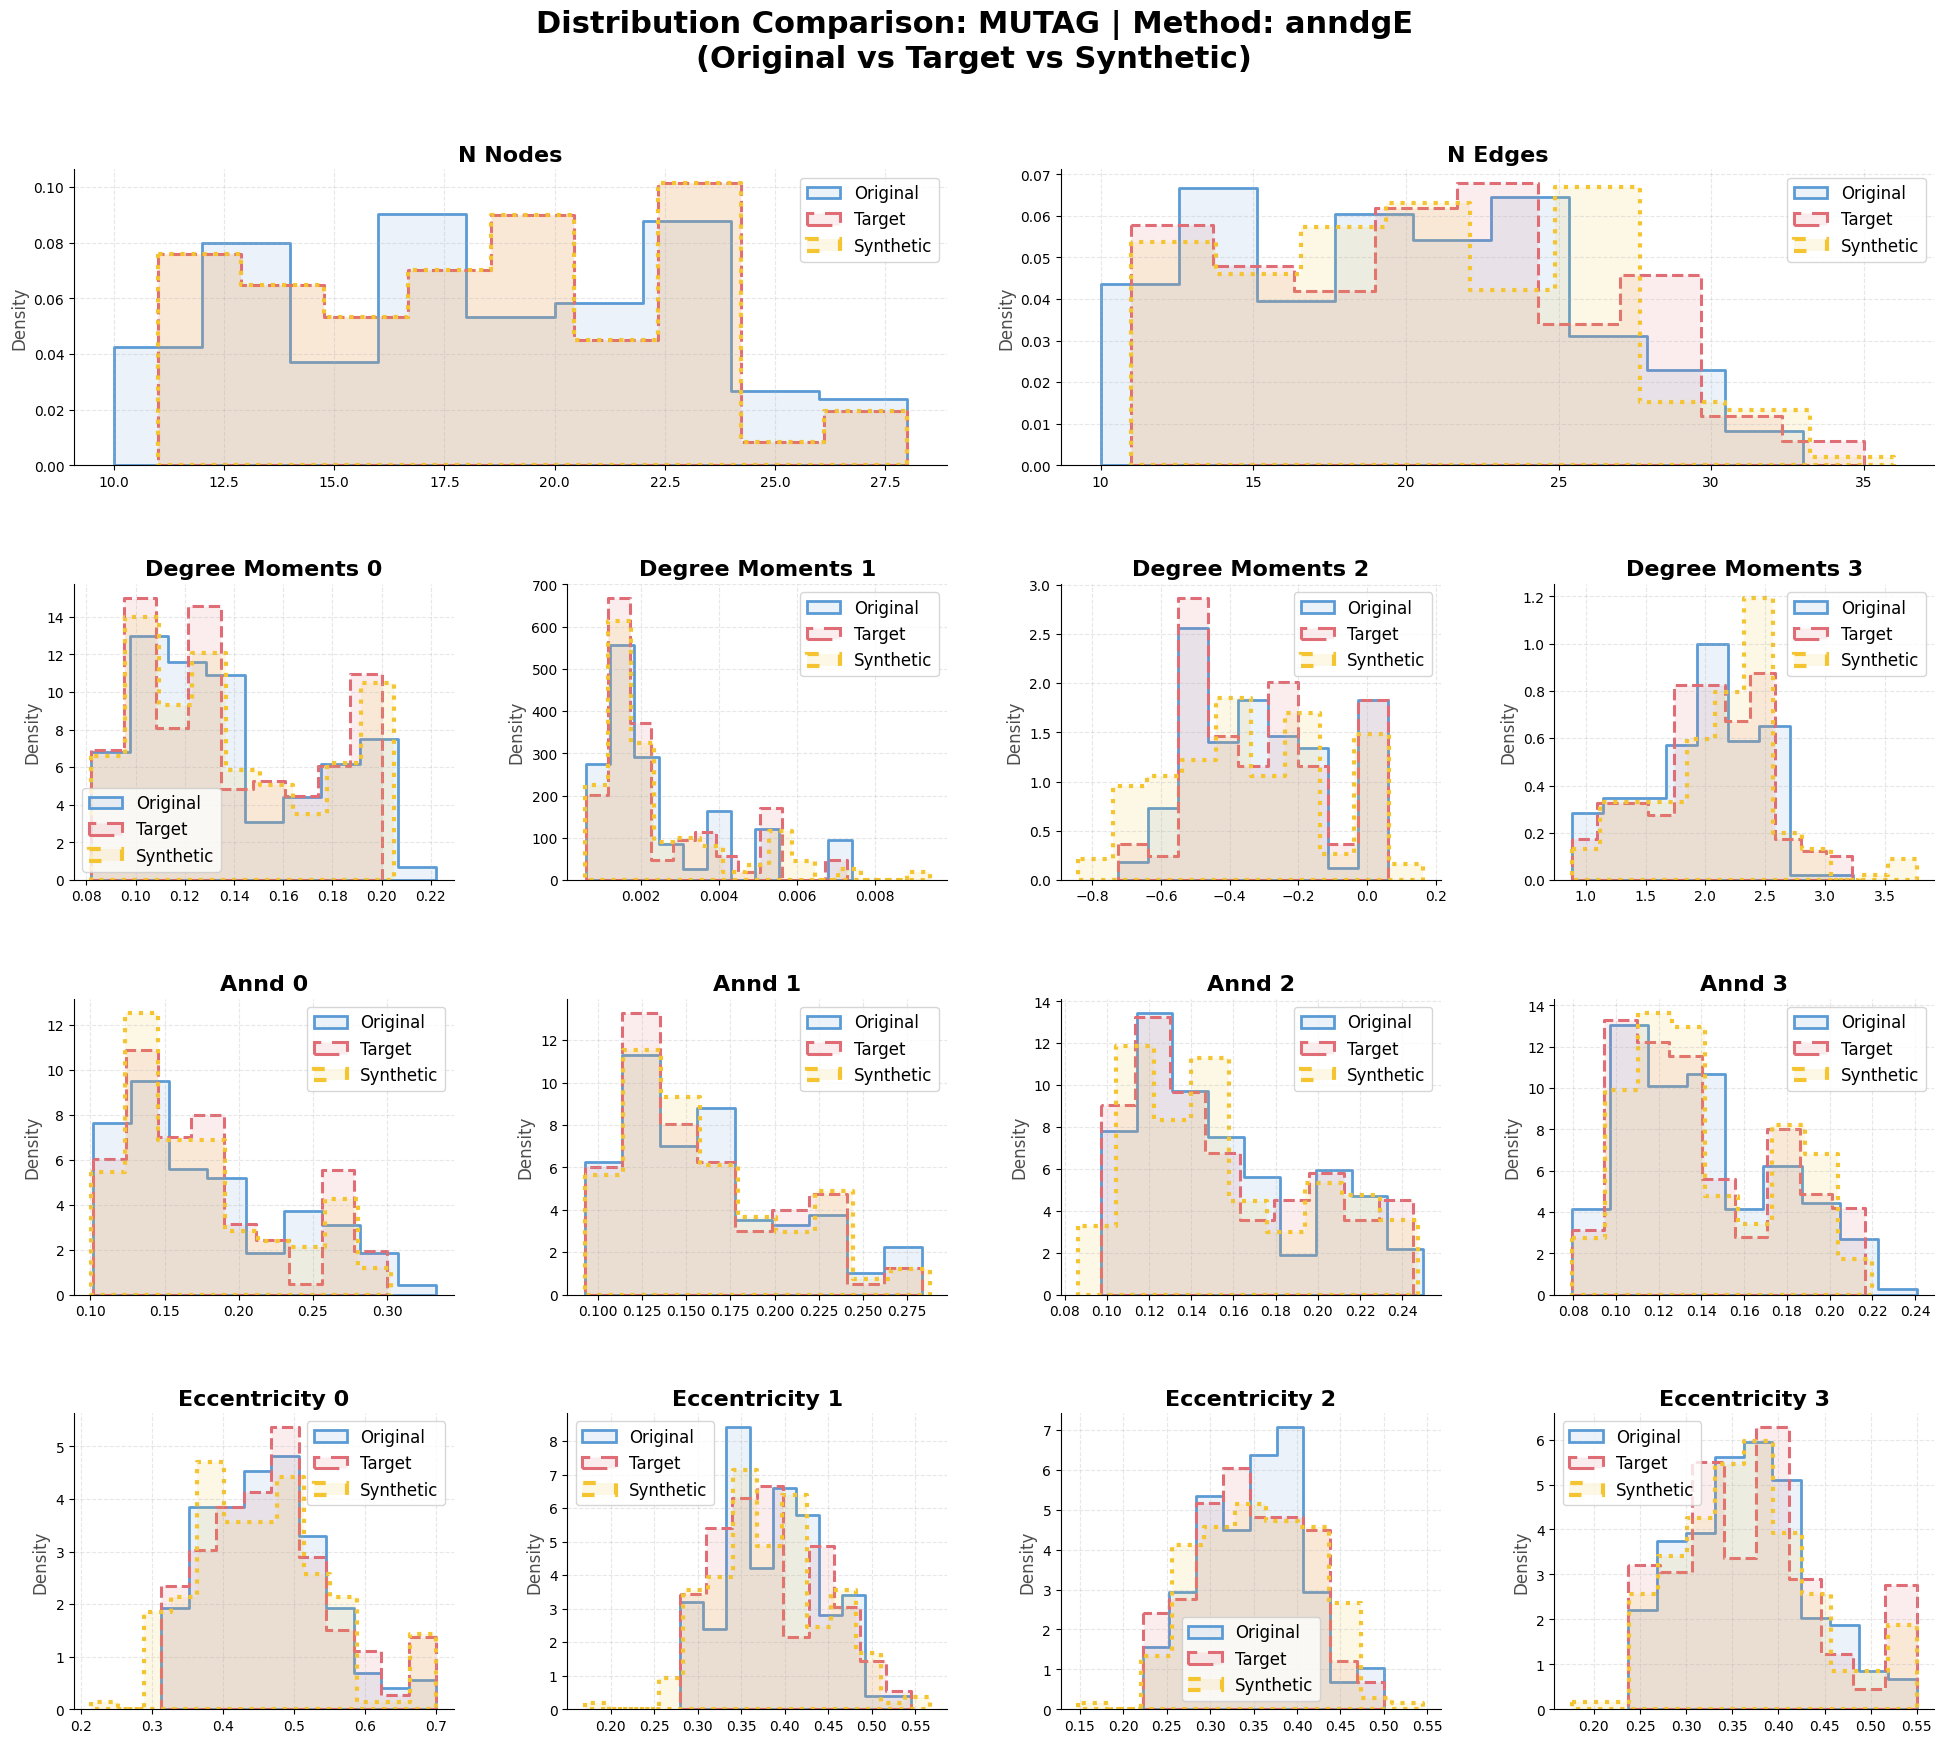


WASSERSTEIN DISTANCES - METHOD: anndgE


n_nodes   n_edges  degree_moments_0  degree_moments_1  \
MUTAG target     0.02172  0.022838          0.023491          0.018772   
      synthetic  0.02172  0.025994          0.025501          0.021497   
MEAN  target     0.02172  0.022838          0.023491          0.018772   
      synthetic  0.02172  0.025994          0.025501          0.021497   

                 degree_moments_2  degree_moments_3    annd_0    annd_1  \
MUTAG target             0.023619          0.024862  0.019136  0.018296   
      synthetic          0.057746          0.051695  0.019451  0.018767   
MEAN  target             0.023619          0.024862  0.019136  0.018296   
      synthetic          0.057746          0.051695  0.019451  0.018767   

                   annd_2    annd_3  eccentricity_0  eccentricity_1  \
MUTAG target     0.019533  0.019160        0.022283        0.024288   
      synthetic  0.021490  0.022558        0.032732        0.022686   
MEAN  target     0.019533  0.019160        0.022283        0.024288   
      synthetic  0.021490  0.022558        0.032732        0.022686   

                 eccentricity_2  eccentricity_3  Global_Score  
MUTAG target           0.023070        0.023178      0.021732  
      synthetic        0.026109        0.022722      0.027905  
MEAN  target           0.023070        0.023178      0.021732  
      synthetic        0.026109        0.022722      0.027905

In [19]:
def compute_wassestrain_distance(df_orig: pd.DataFrame, df_synth: pd.DataFrame, features: list[str]) -> dict[str, float]:
    """Computes the Wasserstein distance for each feature using anchored Min-Max scaling.
    
    Args:
        df_orig: Original dataset DataFrame.
        df_synth: Synthetic (or target) dataset DataFrame.
        features: List of feature names to evaluate.        
    Returns:
        A dictionary mapping feature names to their Wasserstein distance.
    """
    results: dict[str, float] = {}
    
    # Evaluate only features present in both dataframes
    valid_features = [f for f in features if f in df_orig.columns and f in df_synth.columns]
    
    for feat in valid_features:
        orig_values = df_orig[feat].dropna().values
        synth_values = df_synth[feat].dropna().values
        
        if len(orig_values) == 0 or len(synth_values) == 0:
            results[feat] = float("nan")
            continue
            
        # 1. Anchored Min-Max Scaling
        min_val = np.min(orig_values)
        max_val = np.max(orig_values)
        range_val = max_val - min_val
        
        if range_val > 0:
            orig_scaled = (orig_values - min_val) / range_val
            synth_scaled = (synth_values - min_val) / range_val
        else:
            orig_scaled = orig_values - min_val
            synth_scaled = synth_values - min_val
            
        # 2. Wasserstein Distance calculation
        dist = wasserstein_distance(orig_scaled, synth_scaled)
        results[feat] = float(dist)
        
    return results

def plot_method_dataset_comparison(df_orig: pd.DataFrame, df_target: pd.DataFrame, df_synth: pd.DataFrame, dataset_name: str, method_name: str) -> None:
    """Plots overlapping distributions of targeted metrics for original, target, and synthetic datasets."""
    features_grid = [
        ["n_nodes", "n_edges"],
        ["degree_moments_0", "degree_moments_1", "degree_moments_2", "degree_moments_3"],
        ["annd_0", "annd_1", "annd_2", "annd_3"],
        ["eccentricity_0", "eccentricity_1", "eccentricity_2", "eccentricity_3"]
    ]
    n_rows = len(features_grid)
    
    fig = plt.figure(figsize=(24, 5 * n_rows))
    fig.suptitle(
        f"Distribution Comparison: {dataset_name} | Method: {method_name}\n(Original vs Target vs Synthetic)",
        fontsize=22, fontweight="bold", y=0.96
    )
    gs = fig.add_gridspec(n_rows, 4, hspace=0.4, wspace=0.3)
    
    # Map each feature to its computed dynamic subplot
    metrics_map = []
    for r_idx, row_features in enumerate(features_grid):
        col_span = 4 // len(row_features)
        for c_idx, feat in enumerate(row_features):
            start_col = c_idx * col_span
            end_col = start_col + col_span
            ax = fig.add_subplot(gs[r_idx, start_col:end_col])
            metrics_map.append((feat, ax))
        
    plot_configs = [
        (df_orig, "Original", "#5B9BD5", "-", 2.0),
        (df_target, "Target", "#E06C75", "--", 2.2),
        (df_synth, "Synthetic", "#F5C431", ":", 3.0)
    ]
        
    for feat, ax in metrics_map:
        if feat not in df_orig.columns:
            ax.axis("off")
            continue
            
        # Plot distributions
        for data, label, color, linestyle, linewidth in plot_configs:
            if data.empty or feat not in data.columns:
                continue
            sns.histplot(
                data=data, x=feat, ax=ax, label=label,
                color=color, alpha=0.12, stat="density", element="step",
                linewidth=linewidth, linestyle=linestyle, fill=True
            )
        
        ax.set_title(feat.replace("_", " ").title(), fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("Density", fontsize=12, alpha=0.7)
        ax.legend(fontsize=12, frameon=True, facecolor="white", framealpha=0.8)
        ax.grid(True, linestyle="--", alpha=0.3)
        sns.despine(ax=ax)
        
    plt.show()

def evaluate_distribution_distances(df_method: pd.DataFrame, method_name: str, plot_dataset: str = "MUTAG") -> None:
    """Evaluates and displays Wasserstein distances for a single method.
    
    Args:
        df_method: The DataFrame filtered for the current method (and original data).
        method_name: The name of the method being evaluated.
        plot_dataset: The name of the dataset for which to plot distributions comparison.
    """
    method_rows = []
    for dataset in DATASET_NAMES:
        df_sub = df_method[df_method["dataset"] == dataset]
        df_orig = df_sub[df_sub["type"] == "original"]
        df_target = df_sub[df_sub["type"] == "target"]
        df_synth = df_sub[df_sub["type"] == "synthetic"]
        
        if df_orig.empty:
            continue
            
        # Plot overlapping distributions comparison (only for the specified dataset and variant 0)
        if dataset == plot_dataset:
            df_target_plot = df_target[df_target["variant_idx"] == 0] if not df_target.empty else df_target
            df_synth_plot = df_synth[df_synth["variant_idx"] == 0] if not df_synth.empty else df_synth
            plot_method_dataset_comparison(df_orig, df_target_plot, df_synth_plot, dataset, method_name)
            
        # Original vs Target (Targeted features only)
        if not df_target.empty:
            variant_dists = []
            for v_idx in df_target["variant_idx"].unique():
                df_target_var = df_target[df_target["variant_idx"] == v_idx]
                if df_target_var.empty:
                    continue
                var_dist = compute_wassestrain_distance(df_orig, df_target_var, TARGETED_FEATURES)
                variant_dists.append(var_dist)
                
            if variant_dists:
                # Average the metrics across all variants
                df_vars = pd.DataFrame(variant_dists)
                t_dist = df_vars.mean(numeric_only=True).to_dict()
                t_dist["Global_Score"] = float(np.nanmean(list(t_dist.values())))
                t_dist["dataset"] = dataset
                t_dist["comparison"] = "target"
                method_rows.append(t_dist)
            
        # Original vs Synthetic (Targeted features only)
        if not df_synth.empty:
            variant_dists = []
            for v_idx in df_synth["variant_idx"].unique():
                df_synth_var = df_synth[df_synth["variant_idx"] == v_idx]
                if df_synth_var.empty:
                    continue
                var_dist = compute_wassestrain_distance(df_orig, df_synth_var, TARGETED_FEATURES)
                variant_dists.append(var_dist)
                
            if variant_dists:
                # Average the metrics across all variants
                df_vars = pd.DataFrame(variant_dists)
                s_dist = df_vars.mean(numeric_only=True).to_dict()
                s_dist["Global_Score"] = float(np.nanmean(list(s_dist.values())))
                s_dist["dataset"] = dataset
                s_dist["comparison"] = "synthetic"
                method_rows.append(s_dist)
            
    if method_rows:
        df_res = pd.DataFrame(method_rows)
        df_res.set_index(["dataset", "comparison"], inplace=True)
        
        # Reorder columns to preserve TARGETED_FEATURES ordering and append Global_Score
        cols = [c for c in TARGETED_FEATURES if c in df_res.columns] + ["Global_Score"]
        df_res = df_res[cols]
        
        # Calculate means for "target" and "synthetic" comparisons
        mean_target = df_res.xs("target", level="comparison").mean(numeric_only=True)
        mean_target.name = ("MEAN", "target")
        
        mean_synth = df_res.xs("synthetic", level="comparison").mean(numeric_only=True)
        mean_synth.name = ("MEAN", "synthetic")
        
        # Append mean rows to the DataFrame
        df_res = pd.concat([df_res, mean_target.to_frame().T, mean_synth.to_frame().T])
        
        print("\n" + "=" * 100)
        print(f"WASSERSTEIN DISTANCES - METHOD: {method_name}")
        print("=" * 100)
        with pd.option_context("display.max_columns", None):
            display(df_res)


for method in METHODS:
    df_method_subset = df[(df["method"] == method) | (df["type"] == "original")]
    
    if df_method_subset[df_method_subset["method"] == method].empty:
        continue
        
    evaluate_distribution_distances(df_method_subset, method, plot_dataset="MUTAG")

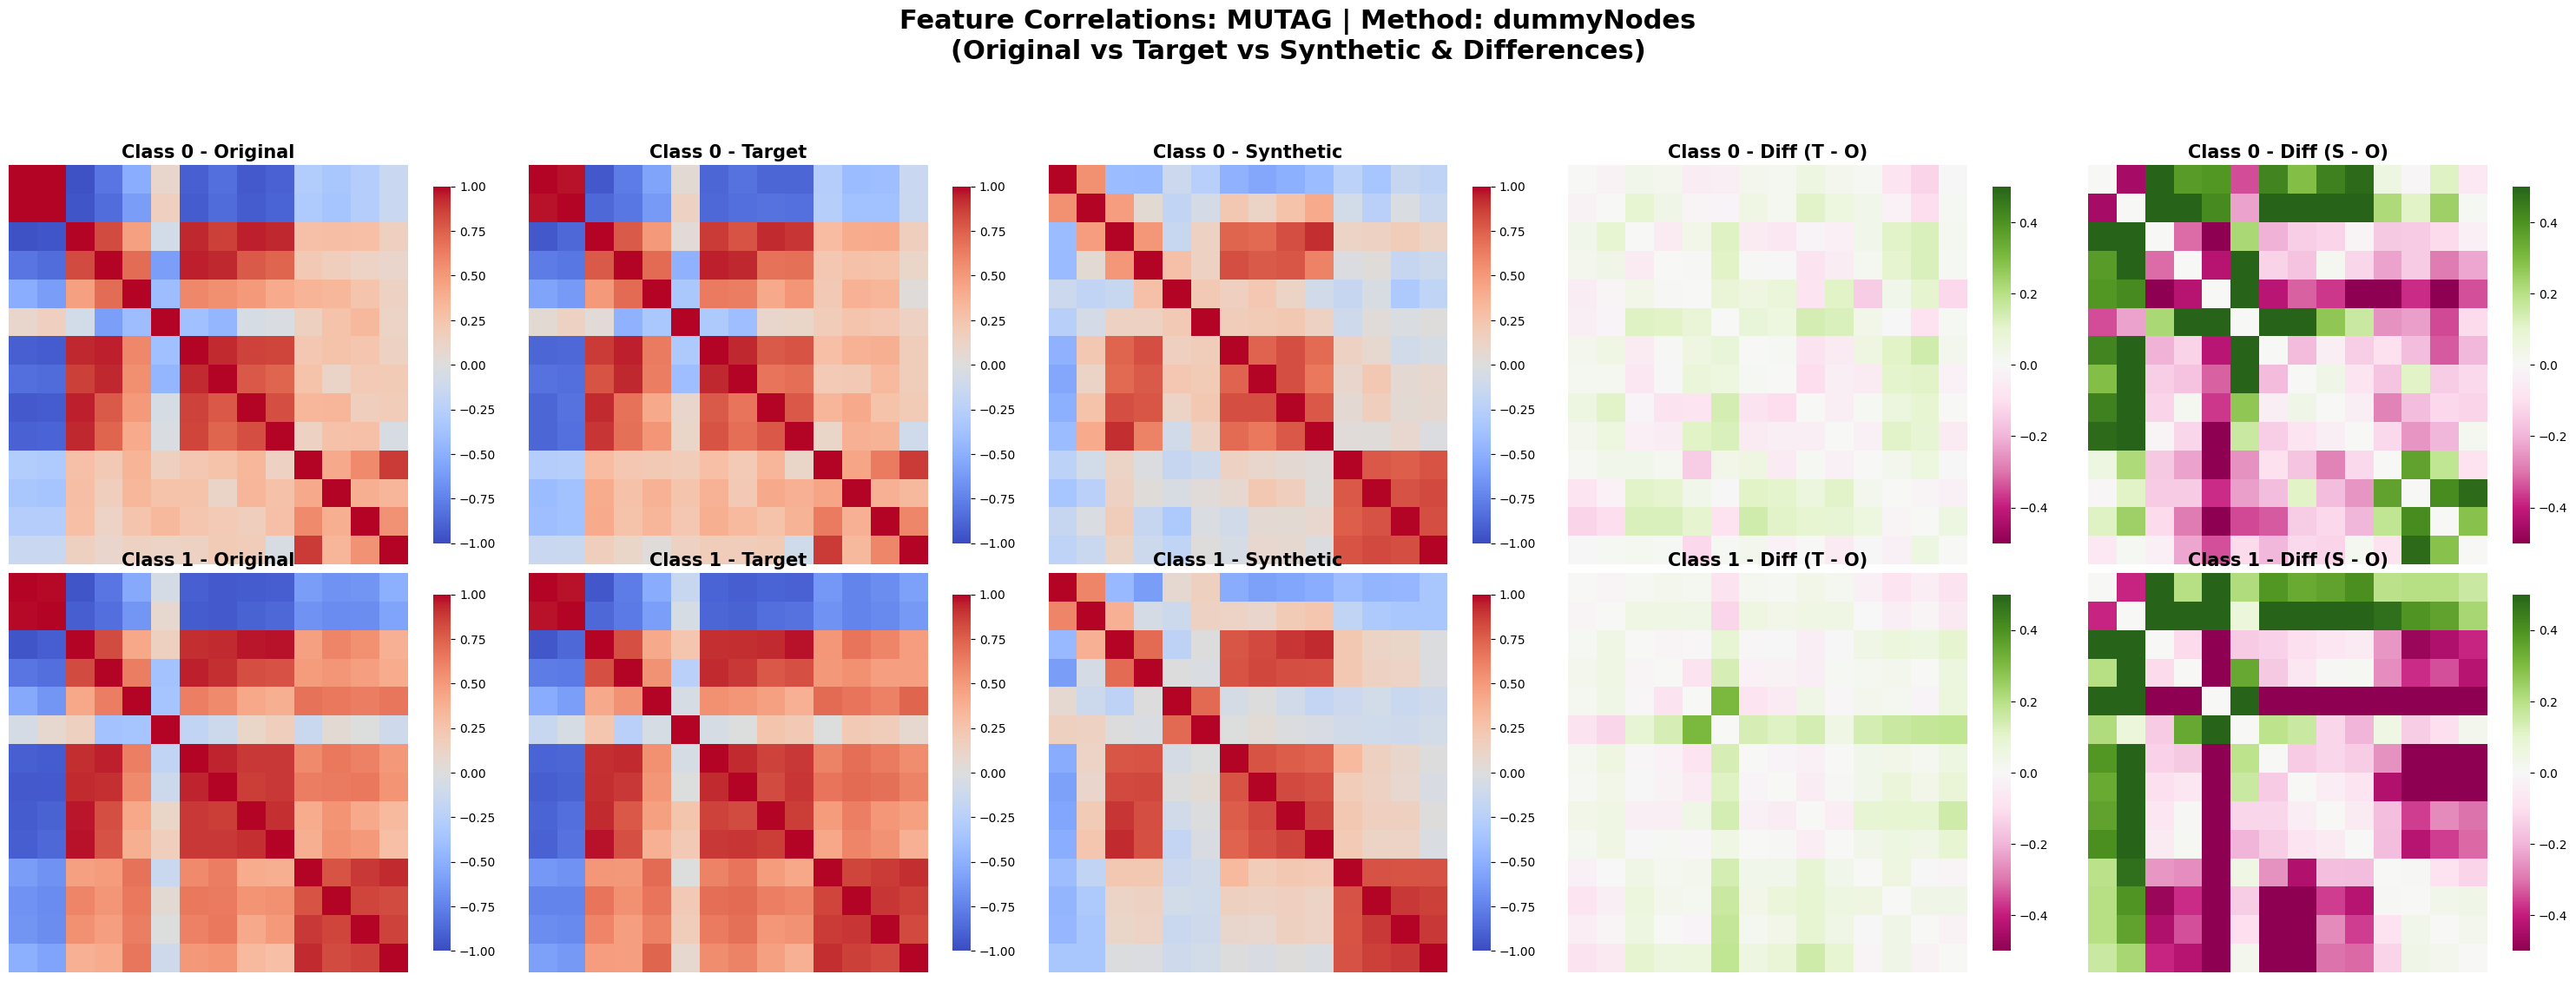


CORRELATION DIFFERENCES - METHOD: dummyNodes


,target_corr_diff,synth_corr_diff
MUTAG,0.066578,0.297041
MEAN,0.066578,0.297041


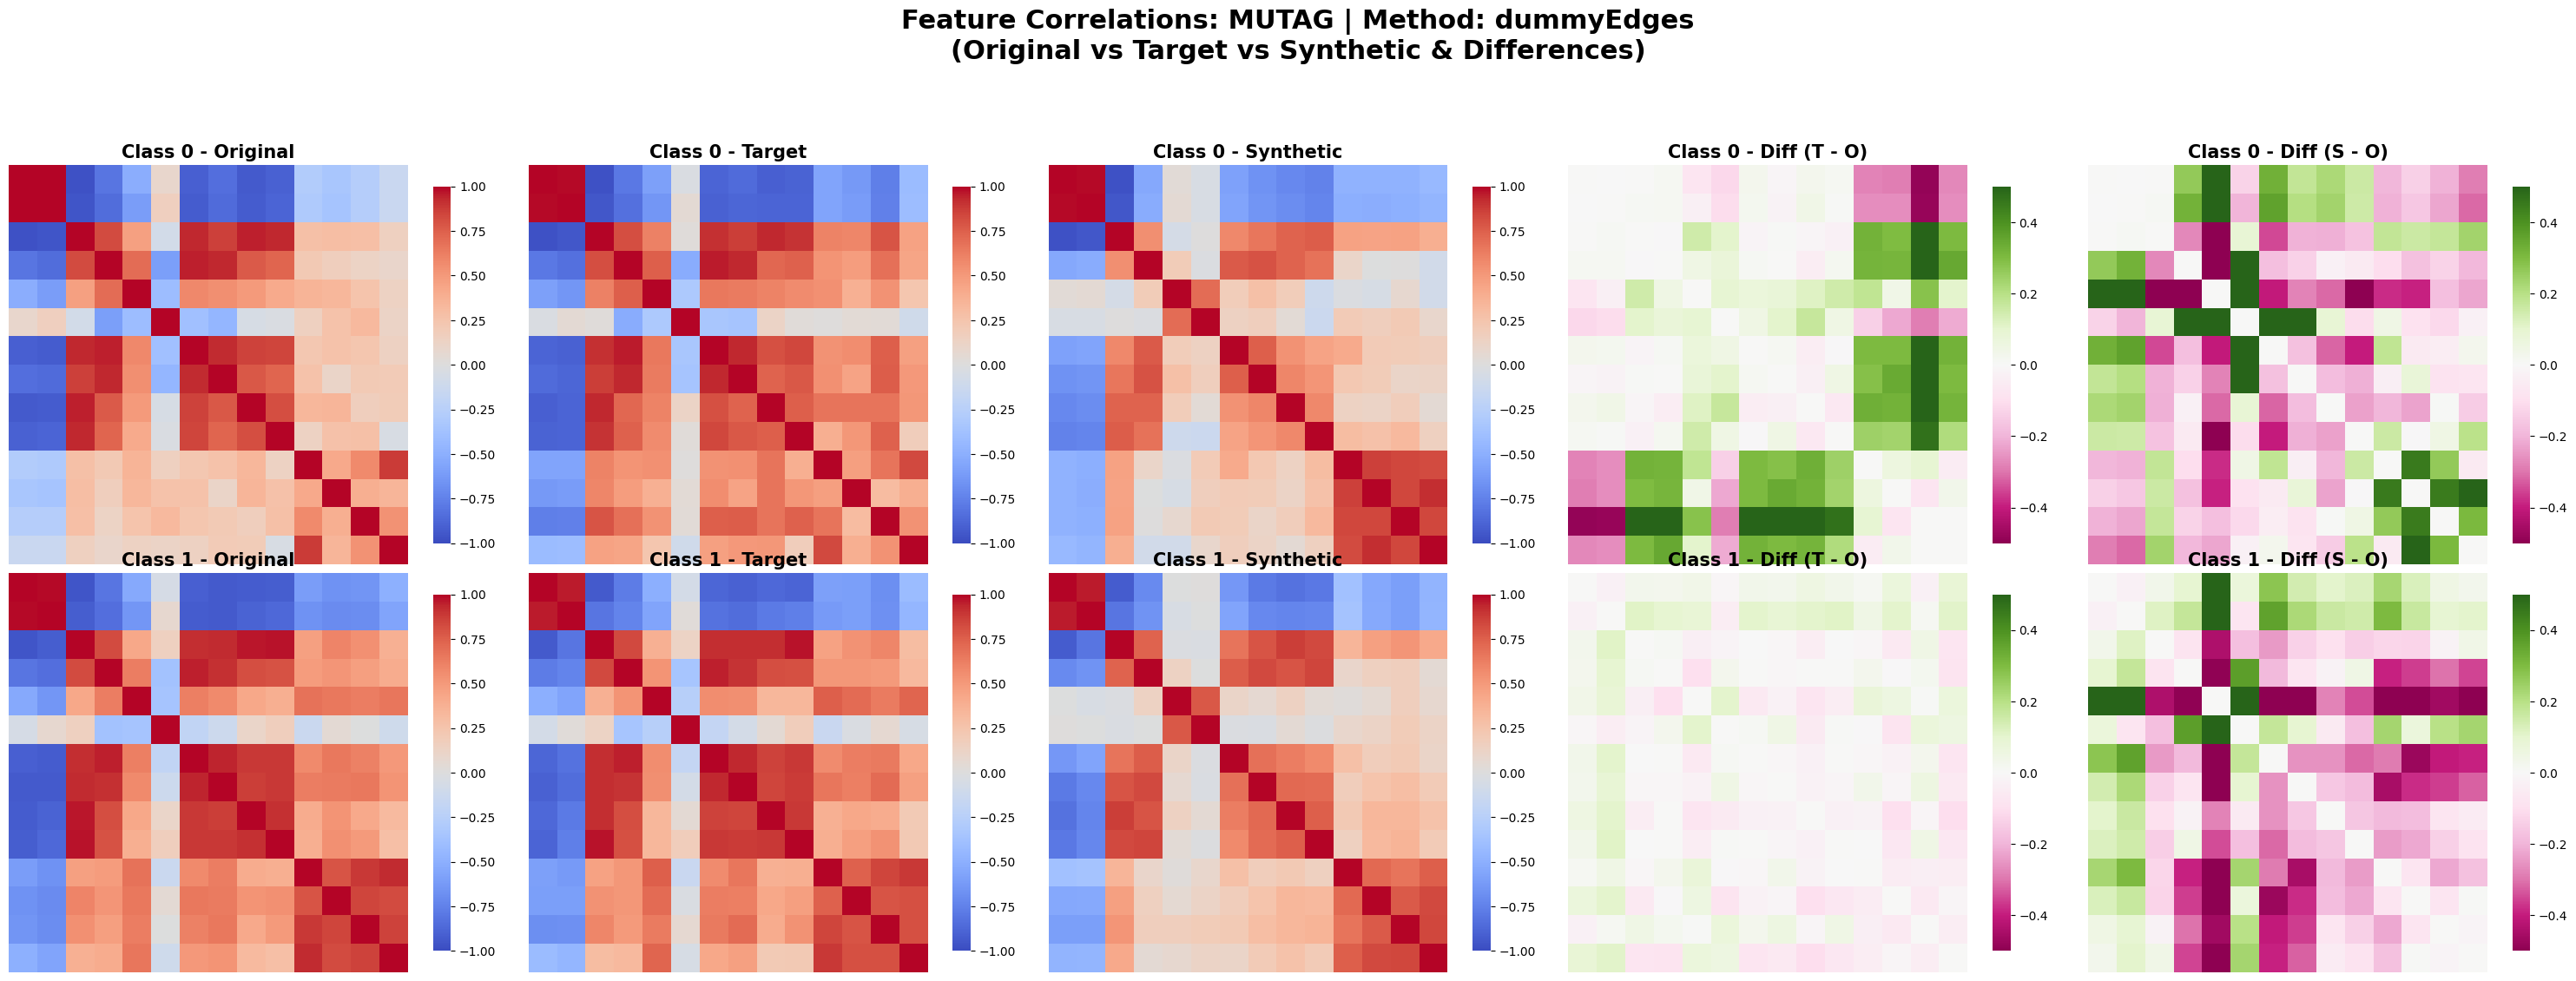


CORRELATION DIFFERENCES - METHOD: dummyEdges


,target_corr_diff,synth_corr_diff
MUTAG,0.073098,0.225926
MEAN,0.073098,0.225926


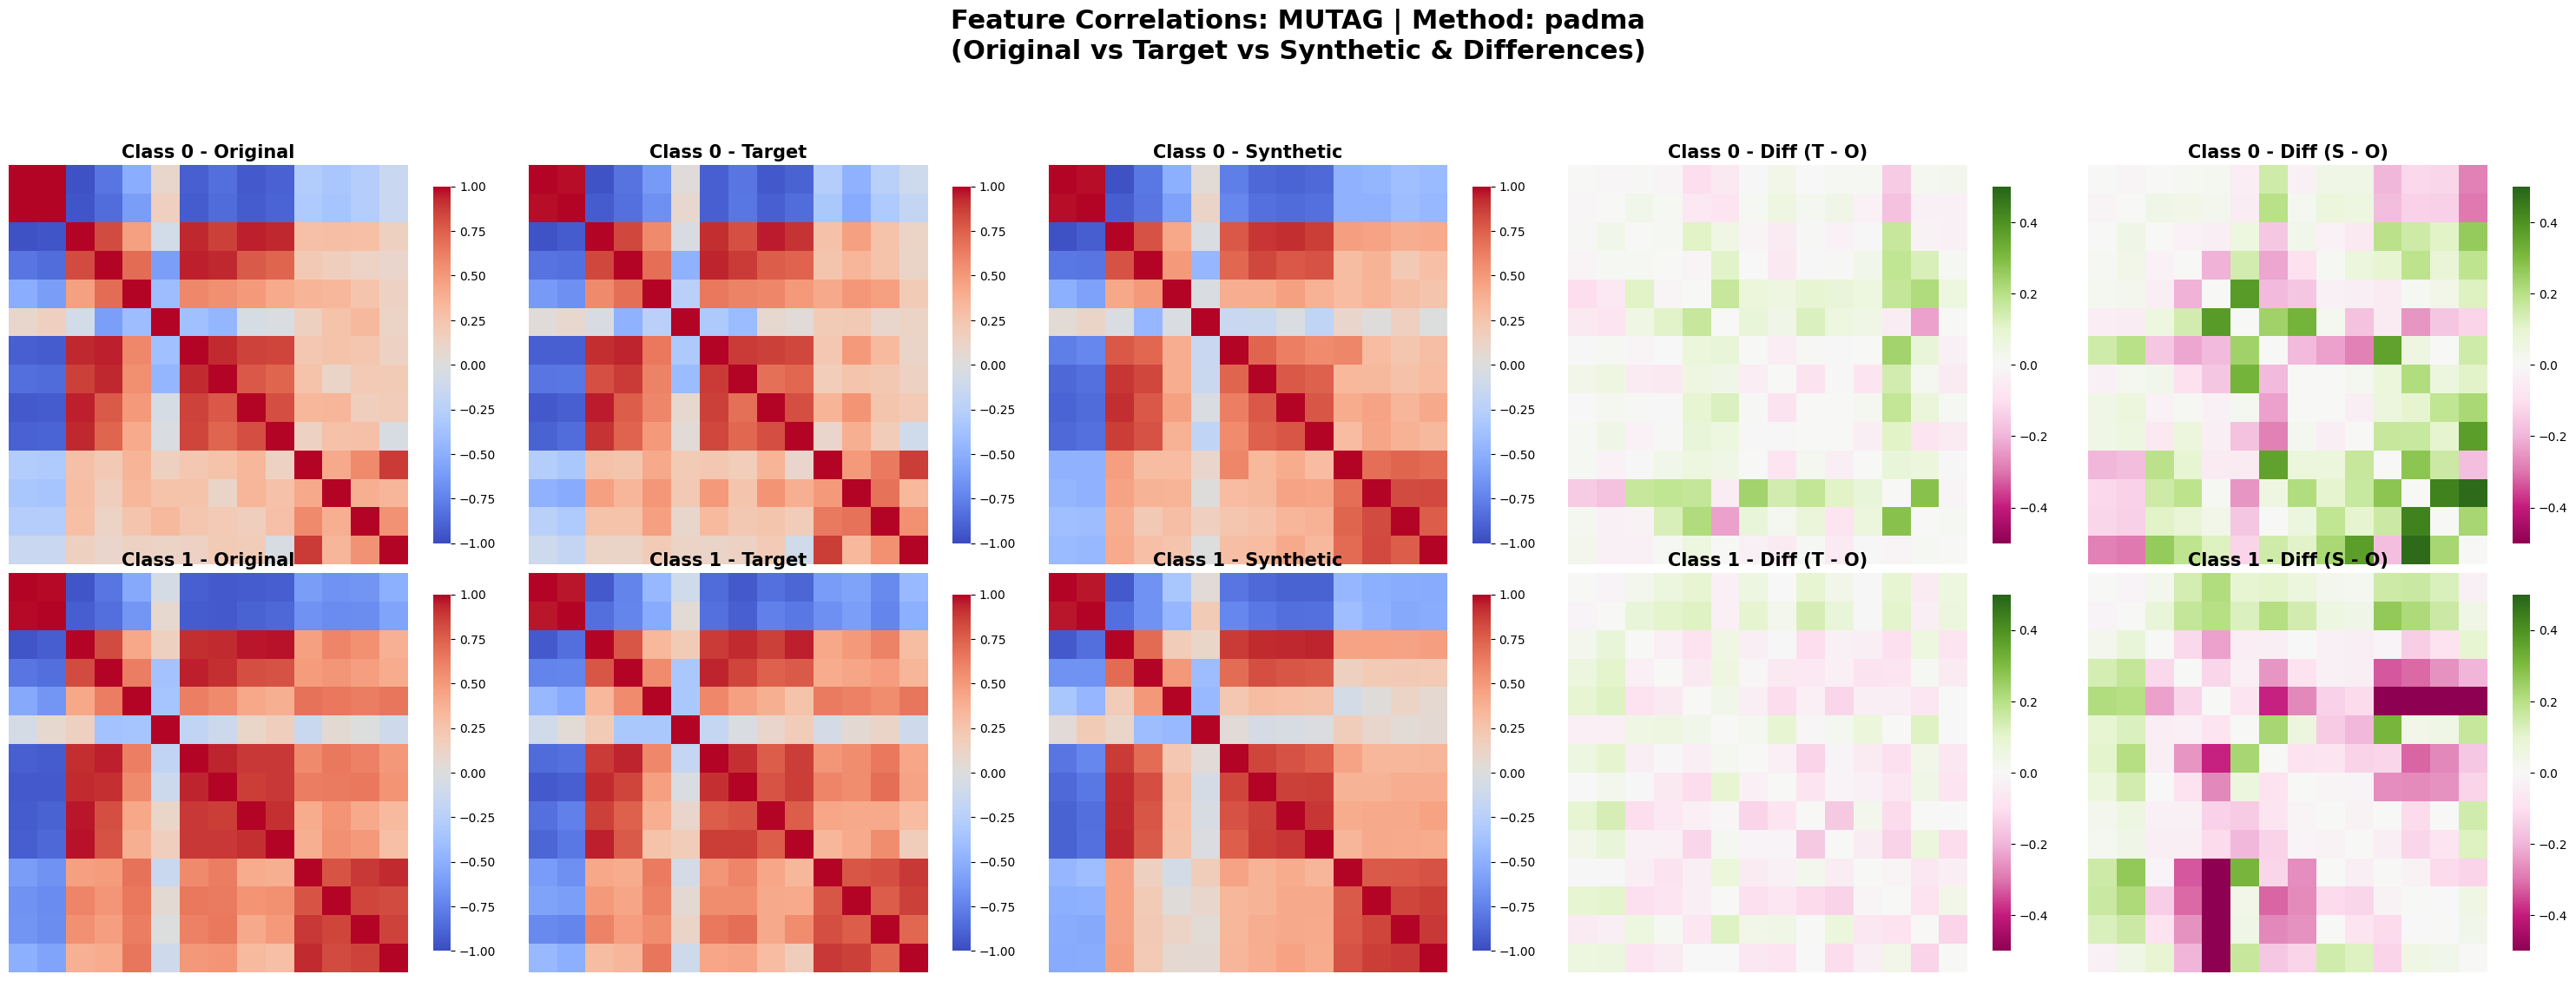


CORRELATION DIFFERENCES - METHOD: padma


,target_corr_diff,synth_corr_diff
MUTAG,0.069608,0.127444
MEAN,0.069608,0.127444


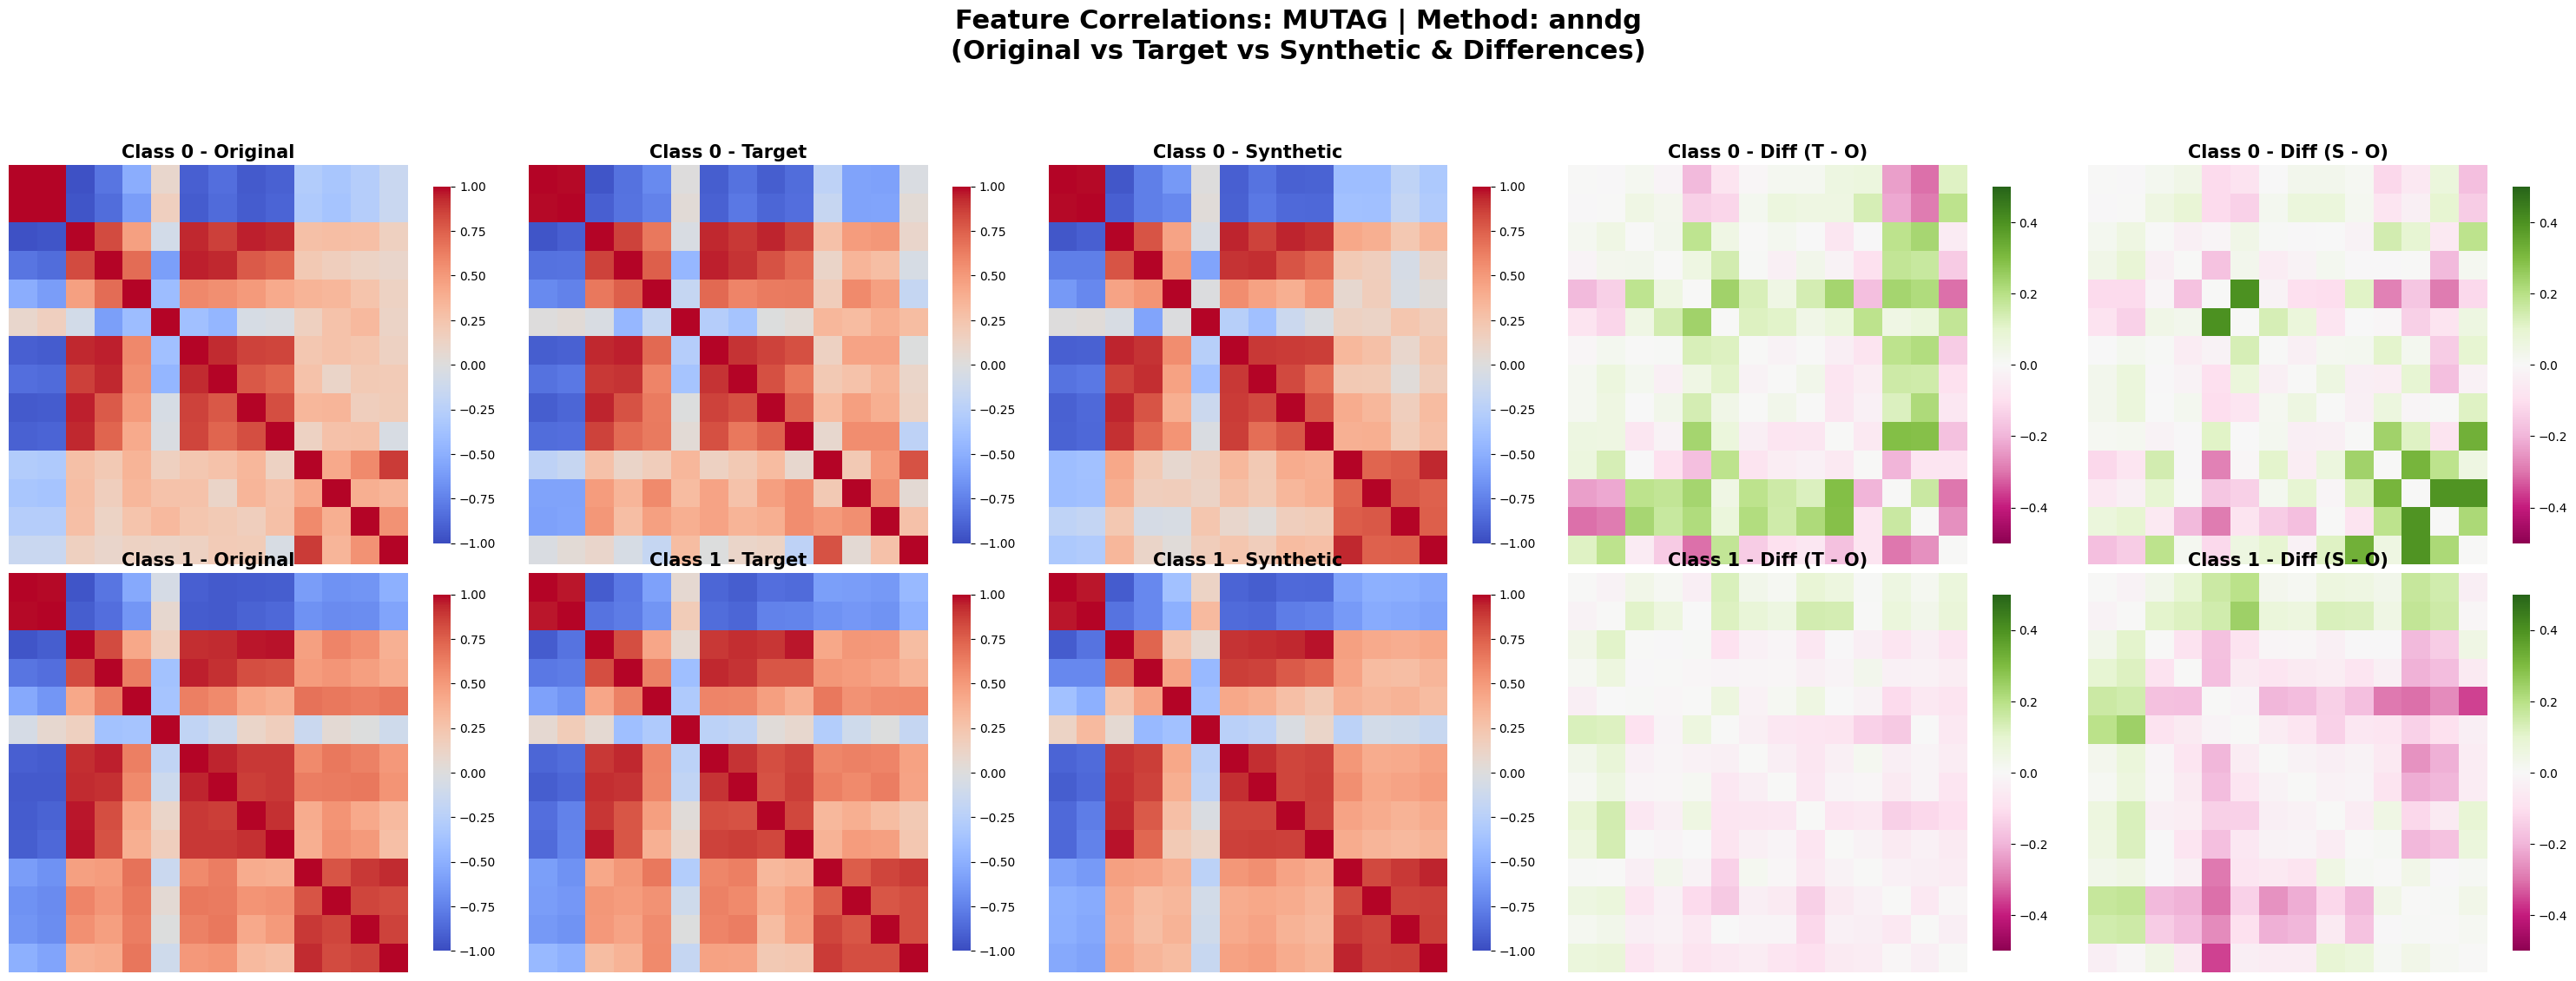


CORRELATION DIFFERENCES - METHOD: anndg


,target_corr_diff,synth_corr_diff
MUTAG,0.066471,0.097632
MEAN,0.066471,0.097632


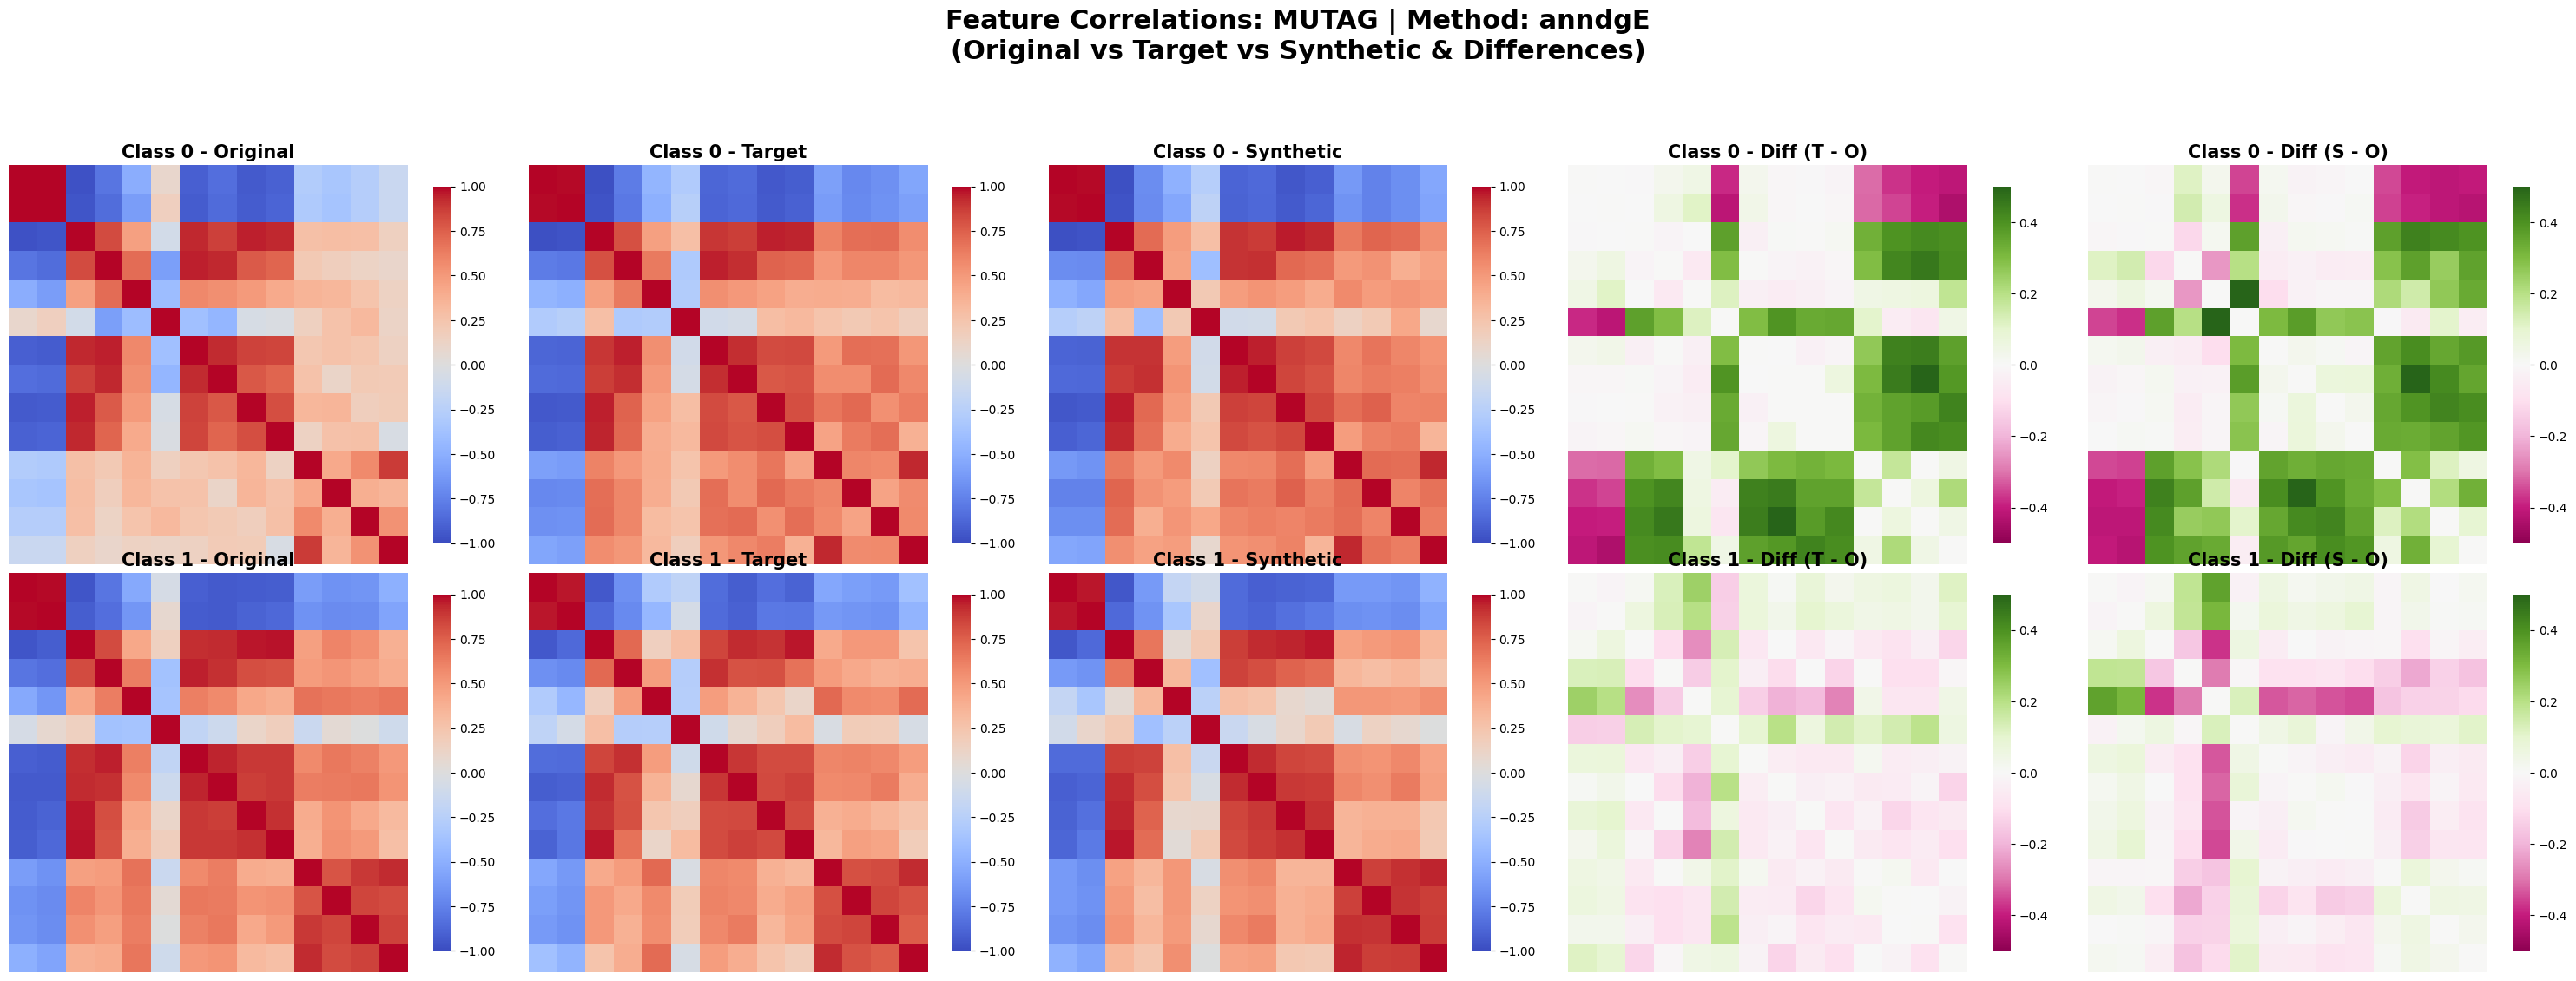


CORRELATION DIFFERENCES - METHOD: anndgE


,target_corr_diff,synth_corr_diff
MUTAG,0.073373,0.089984
MEAN,0.073373,0.089984


In [20]:
def plot_correlation_comparison(
    df_orig: pd.DataFrame,
    df_target: pd.DataFrame,
    df_synth: pd.DataFrame,
    dataset_name: str,
    method_name: str
) -> None:
    """Plots correlation heatmaps and differences for original, target, and synthetic data.
    
    Args:
        df_orig: Original dataset DataFrame
        df_target: Target dataset DataFrame
        df_synth: Synthetic dataset DataFrame
        dataset_name: Name of the dataset
        method_name: Name of the generation method
    """
    classes = [0, 1]
    n_classes = len(classes)
    
    # Use only variant_idx == 0 for plotting target/synth to be representative and clean
    df_target_var0 = df_target[df_target["variant_idx"] == 0] if not df_target.empty else df_target
    df_synth_var0 = df_synth[df_synth["variant_idx"] == 0] if not df_synth.empty else df_synth
    
    # 5-column layout: Original, Target, Synthetic, Target Diff (T - O), Synth Diff (S - O)
    fig, axes = plt.subplots(n_classes, 5, figsize=(30, 6 * n_classes))
    if n_classes == 1:
        axes = axes.reshape(1, 5)
        
    fig.suptitle(
        f"Feature Correlations: {dataset_name} | Method: {method_name}\n(Original vs Target vs Synthetic & Differences)",
        fontsize=22,
        fontweight="bold",
        y=0.99
    )
    
    heatmap_kwargs = {
        "center": 0,
        "annot": False,
        "square": True,
        "cbar_kws": {"shrink": 0.8},
        "xticklabels": False,
        "yticklabels": False
    }
    
    for i, class_id in enumerate(classes):
        orig_cls = df_orig[df_orig["class_id"] == class_id]
        target_cls = df_target_var0[df_target_var0["class_id"] == class_id] if not df_target_var0.empty else pd.DataFrame()
        synth_cls = df_synth_var0[df_synth_var0["class_id"] == class_id] if not df_synth_var0.empty else pd.DataFrame()
        
        if orig_cls.empty:
            # Skip class if original data is empty
            for col in range(5):
                axes[i, col].axis("off")
            continue
            
        corr_orig = orig_cls[TARGETED_FEATURES].corr().fillna(0)
        
        # 1. Original
        sns.heatmap(corr_orig, ax=axes[i, 0], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
        axes[i, 0].set_title(f"Class {class_id} - Original", fontsize=15, fontweight="bold")
        
        # 2. Target
        if not target_cls.empty:
            corr_target = target_cls[TARGETED_FEATURES].corr().fillna(0)
            sns.heatmap(corr_target, ax=axes[i, 1], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
            axes[i, 1].set_title(f"Class {class_id} - Target", fontsize=15, fontweight="bold")
            
            corr_diff_target = corr_target - corr_orig
            sns.heatmap(corr_diff_target, ax=axes[i, 3], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
            axes[i, 3].set_title(f"Class {class_id} - Diff (T - O)", fontsize=15, fontweight="bold")
        else:
            axes[i, 1].axis("off")
            axes[i, 3].axis("off")
            
        # 3. Synthetic
        if not synth_cls.empty:
            corr_synth = synth_cls[TARGETED_FEATURES].corr().fillna(0)
            sns.heatmap(corr_synth, ax=axes[i, 2], cmap="coolwarm", vmin=-1, vmax=1, **heatmap_kwargs)
            axes[i, 2].set_title(f"Class {class_id} - Synthetic", fontsize=15, fontweight="bold")
            
            corr_diff_synth = corr_synth - corr_orig
            sns.heatmap(corr_diff_synth, ax=axes[i, 4], cmap="PiYG", vmin=-0.5, vmax=0.5, **heatmap_kwargs)
            axes[i, 4].set_title(f"Class {class_id} - Diff (S - O)", fontsize=15, fontweight="bold")
        else:
            axes[i, 2].axis("off")
            axes[i, 4].axis("off")
            
    plt.tight_layout(rect=[0, 0.03, 1, 0.94])
    plt.show()


def evaluate_correlation_distances(
    df_method: pd.DataFrame,
    method_name: str,
    plot_dataset: str = "MUTAG"
) -> None:
    """Evaluates and displays global targeted correlation differences for a single method.
    
    Args:
        df_method: The DataFrame filtered for the current method (and original data).
        method_name: The name of the method being evaluated.
        plot_dataset: The name of the dataset for which to plot correlation matrices.
    """
    method_rows = []
    
    for dataset in DATASET_NAMES:
        df_sub = df_method[df_method["dataset"] == dataset]
        df_orig = df_sub[df_sub["type"] == "original"]
        df_target = df_sub[df_sub["type"] == "target"]
        df_synth = df_sub[df_sub["type"] == "synthetic"]
        
        if df_orig.empty:
            continue
            
        # Plot correlation comparison (only for specified dataset and variant 0)
        if dataset == plot_dataset:
            plot_correlation_comparison(df_orig, df_target, df_synth, dataset, method_name)
            
        # Calculate global correlation MAE across classes and variants
        classes = [0, 1]
        
        # 1. Target correlation difference
        target_maes = []
        if not df_target.empty:
            for c_id in classes:
                df_orig_cls = df_orig[df_orig["class_id"] == c_id]
                if df_orig_cls.empty:
                    continue
                corr_orig = df_orig_cls[TARGETED_FEATURES].corr().fillna(0).values
                
                for v_idx in df_target["variant_idx"].unique():
                    df_target_var = df_target[(df_target["variant_idx"] == v_idx) & (df_target["class_id"] == c_id)]
                    if df_target_var.empty:
                        continue
                    corr_target = df_target_var[TARGETED_FEATURES].corr().fillna(0).values
                    mae = float(np.mean(np.abs(corr_target - corr_orig)))
                    target_maes.append(mae)
                    
        # 2. Synthetic correlation difference
        synth_maes = []
        if not df_synth.empty:
            for c_id in classes:
                df_orig_cls = df_orig[df_orig["class_id"] == c_id]
                if df_orig_cls.empty:
                    continue
                corr_orig = df_orig_cls[TARGETED_FEATURES].corr().fillna(0).values
                
                for v_idx in df_synth["variant_idx"].unique():
                    df_synth_var = df_synth[(df_synth["variant_idx"] == v_idx) & (df_synth["class_id"] == c_id)]
                    if df_synth_var.empty:
                        continue
                    corr_synth = df_synth_var[TARGETED_FEATURES].corr().fillna(0).values
                    mae = float(np.mean(np.abs(corr_synth - corr_orig)))
                    synth_maes.append(mae)
                    
        # Aggregate stats
        row = {"dataset": dataset}
        if target_maes:
            row["target_corr_diff"] = float(np.mean(target_maes))
        else:
            row["target_corr_diff"] = float("nan")
            
        if synth_maes:
            row["synth_corr_diff"] = float(np.mean(synth_maes))
        else:
            row["synth_corr_diff"] = float("nan")
            
        method_rows.append(row)
        
    if method_rows:
        df_res = pd.DataFrame(method_rows)
        df_res.set_index("dataset", inplace=True)
        
        # Calculate MEAN rows for both difference metrics
        mean_row = df_res.mean(numeric_only=True)
        mean_row.name = "MEAN"
        df_res = pd.concat([df_res, mean_row.to_frame().T])
        
        print("\n" + "=" * 100)
        print(f"CORRELATION DIFFERENCES - METHOD: {method_name}")
        print("=" * 100)
        with pd.option_context("display.max_columns", None):
            display(df_res)


# Execute global correlation evaluation for each method
for method in METHODS:
    df_method_subset = df[(df["method"] == method) | (df["type"] == "original")]
    
    if df_method_subset[df_method_subset["method"] == method].empty:
        continue
        
    evaluate_correlation_distances(df_method_subset, method, plot_dataset="MUTAG")